# **SmileSage 2.0: Multi-Model Dental Classification System**

## Overview
This notebook implements a comprehensive comparison of multiple state-of-the-art deep learning models for dental condition classification. The system evaluates 10 different pre-trained models using transfer learning techniques to identify the best performing architecture for dental health diagnostics.

### Key Features:
- **Multi-model comparison**: EfficientNet variants, ResNet, DenseNet, Inception, VGG, MobileNet, and ConvNeXt
- **Systematic evaluation**: Standardized training, validation, and testing protocols
- **Transfer learning**: Leverages ImageNet pre-trained weights with fine-tuning
- **Comprehensive analysis**: Detailed performance metrics, visualizations, and reports
- **Production-ready**: Best model selection with deployment considerations

---


In [ ]:
# ==================== CELL 1: SETUP & IMPORTS ====================
from google.colab import drive, files
import os
import matplotlib.pyplot as plt
import cv2
import random
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers, models, callbacks, applications
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.cm as cm
from PIL import Image
from IPython.display import display
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set random seeds for reproducibility
tf.random.set_seed(123)
np.random.seed(123)
random.seed(123)

# Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')
print("✅ Google Drive mounted successfully!")

Mounting Google Drive...
Mounted at /content/drive
✅ Google Drive mounted successfully!


In [ ]:
# ==================== CELL 2: CONFIGURATION ====================
# Dataset configuration
DATASET_PATH = '/content/drive/MyDrive/revised_dental_dataset'
RESULTS_BASE_PATH = '/content/drive/MyDrive/dental_models_comparison'

# Create results directory
os.makedirs(RESULTS_BASE_PATH, exist_ok=True)

# Model configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123
EPOCHS = 50
PATIENCE = 7

# Define class names (CRITICAL FOR CONSISTENCY)
CLASS_NAMES = [
    "Calculus",
    "Caries",
    "Gingivitis",
    "Healthy",
    "Hypodontia",
    "Tooth_discoloration",
    "Ulcers"
]
NUM_CLASSES = len(CLASS_NAMES)

# Models to compare
MODELS_TO_COMPARE = [
    'EfficientNetV2S',
    'ResNet50V2',
    'DenseNet121',
    'DenseNet201',
    'InceptionV3',
    'VGG16',
    'EfficientNetB0',
    'EfficientNetB3',
    'MobileNetV2',
    'ConvNeXt-Tiny'
]

print(f"📊 Dataset: {DATASET_PATH}")
print(f"🎯 Classes: {CLASS_NAMES}")
print(f"📈 Total Classes: {NUM_CLASSES}")
print(f"🔬 Models to compare: {len(MODELS_TO_COMPARE)}")

📊 Dataset: /content/drive/MyDrive/revised_dental_dataset
🎯 Classes: ['Calculus', 'Caries', 'Gingivitis', 'Healthy', 'Hypodontia', 'Tooth_discoloration', 'Ulcers']
📈 Total Classes: 7
🔬 Models to compare: 10


=== DATASET EXPLORATION ===
✅ Calculus: 1213 images
✅ Caries: 1210 images
✅ Gingivitis: 1202 images
✅ Healthy: 1208 images
✅ Hypodontia: 1200 images
✅ Tooth_discoloration: 1200 images
✅ Ulcers: 1200 images

📊 Class Distribution:
                     Image Count
Calculus                    1213
Caries                      1210
Gingivitis                  1202
Healthy                     1208
Hypodontia                  1200
Tooth_discoloration         1200
Ulcers                      1200


<Figure size 1200x600 with 0 Axes>

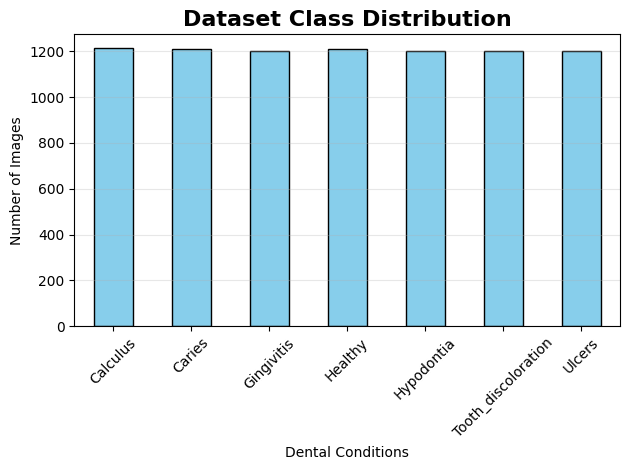


=== SAMPLE IMAGES ===


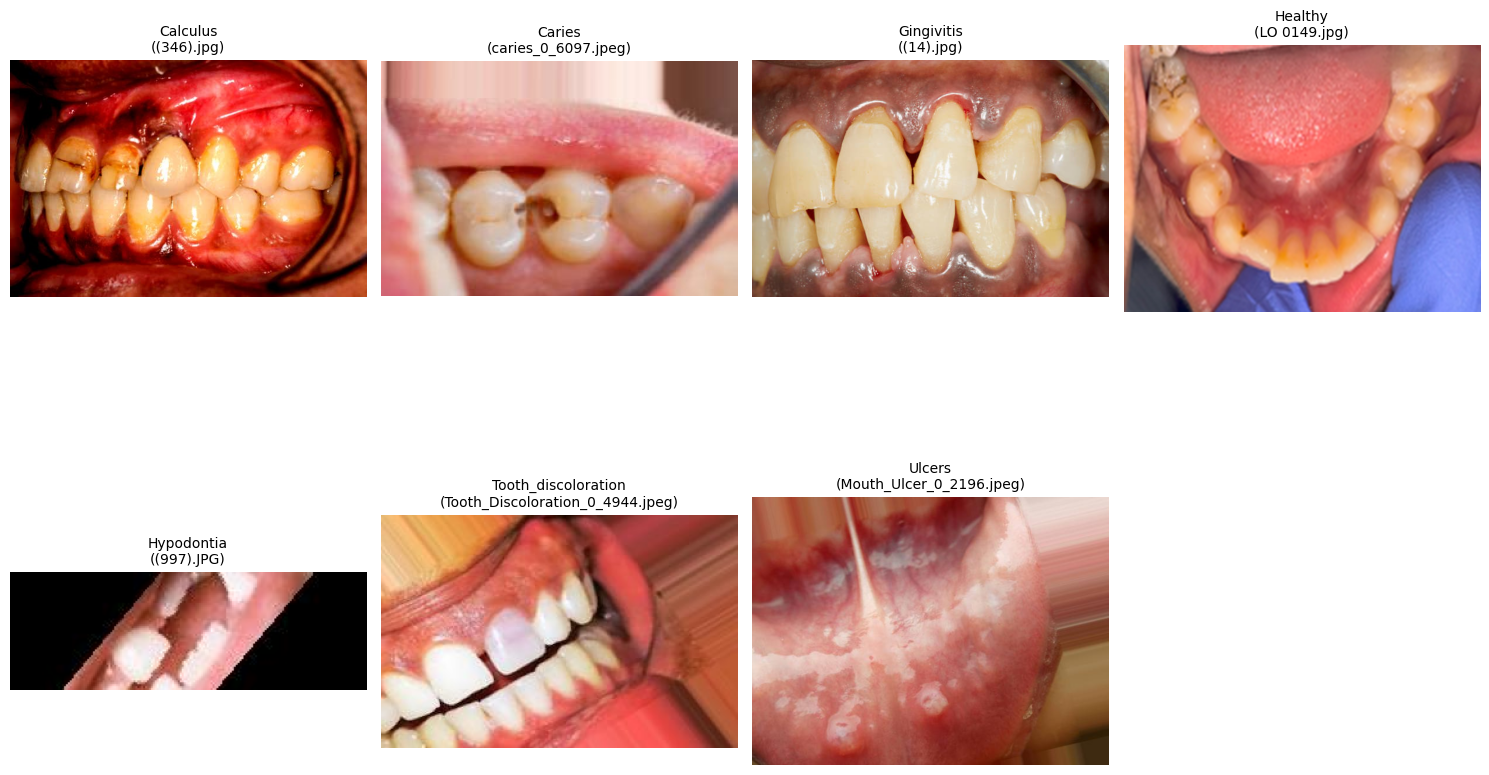

In [ ]:
# ==================== CELL 3: DATA EXPLORATION ====================
def explore_dataset():
    """Explore dataset structure and class distribution"""
    print("=== DATASET EXPLORATION ===")

    # Check folder structure
    class_counts = {}
    for folder in CLASS_NAMES:
        folder_path = os.path.join(DATASET_PATH, folder)
        if os.path.exists(folder_path):
            num_images = len(os.listdir(folder_path))
            class_counts[folder] = num_images
            print(f"✅ {folder}: {num_images} images")
        else:
            print(f"❌ Missing folder: {folder}")

    # Create distribution DataFrame
    df = pd.DataFrame.from_dict(class_counts, orient='index', columns=['Image Count'])
    print(f"\n📊 Class Distribution:\n{df}")

    # Plot distribution
    plt.figure(figsize=(12, 6))
    df.plot(kind='bar', legend=False, color='skyblue', edgecolor='black')
    plt.title('Dataset Class Distribution', fontsize=16, fontweight='bold')
    plt.ylabel('Number of Images')
    plt.xlabel('Dental Conditions')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return class_counts

def visualize_samples():
    """Display sample images from each class"""
    print("\n=== SAMPLE IMAGES ===")
    plt.figure(figsize=(15, 10))

    for i, cls in enumerate(CLASS_NAMES):
        folder_path = os.path.join(DATASET_PATH, cls)
        if not os.path.exists(folder_path):
            continue

        # Get random sample
        sample_images = os.listdir(folder_path)
        sample_image = random.choice(sample_images)
        img_path = os.path.join(folder_path, sample_image)

        # Load and display
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 4, i+1)
        plt.imshow(img)
        plt.title(f"{cls}\n({sample_image})", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run exploration
class_counts = explore_dataset()
visualize_samples()

In [ ]:
# ==================== CELL 4: DATA LOADING & PREPROCESSING ====================
def create_datasets():
    """Create train, validation, and test datasets"""
    print("=== CREATING DATASETS ===")

    # Create train/val split
    train_ds = image_dataset_from_directory(
        DATASET_PATH,
        validation_split=0.3,
        subset='training',
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_names=CLASS_NAMES
    )

    val_ds = image_dataset_from_directory(
        DATASET_PATH,
        validation_split=0.3,
        subset='validation',
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_names=CLASS_NAMES
    )

    # Split validation into val/test
    val_batches = tf.data.experimental.cardinality(val_ds)
    test_ds = val_ds.take(val_batches // 2)
    val_ds = val_ds.skip(val_batches // 2)

    print(f"📦 Train batches: {tf.data.experimental.cardinality(train_ds)}")
    print(f"📦 Validation batches: {tf.data.experimental.cardinality(val_ds)}")
    print(f"📦 Test batches: {tf.data.experimental.cardinality(test_ds)}")

    return train_ds, val_ds, test_ds

def setup_preprocessing():
    """Setup data augmentation and preprocessing"""
    print("=== SETTING UP PREPROCESSING ===")

    # Data augmentation (conservative for medical images)
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.05),
    ], name="data_augmentation")

    return data_augmentation

def apply_preprocessing(train_ds, val_ds, test_ds, data_augmentation, preprocess_fn):
    """Apply preprocessing to datasets"""
    AUTOTUNE = tf.data.AUTOTUNE

    # Apply to training set (with augmentation)
    train_ds = (
        train_ds
        .map(lambda x, y: (data_augmentation(x), y), num_parallel_calls=AUTOTUNE)
        .map(preprocess_fn, num_parallel_calls=AUTOTUNE)
        .shuffle(1000)
        .cache()
        .prefetch(buffer_size=AUTOTUNE)
    )

    # Apply to validation set (no augmentation)
    val_ds = (
        val_ds
        .map(preprocess_fn, num_parallel_calls=AUTOTUNE)
        .cache()
        .prefetch(buffer_size=AUTOTUNE)
    )

    # Apply to test set (no augmentation)
    test_ds = (
        test_ds
        .map(preprocess_fn, num_parallel_calls=AUTOTUNE)
        .cache()
        .prefetch(buffer_size=AUTOTUNE)
    )

    print("✅ Preprocessing applied to all datasets")
    return train_ds, val_ds, test_ds

# Create base datasets (will be preprocessed differently for each model)
train_ds_base, val_ds_base, test_ds_base = create_datasets()
data_augmentation = setup_preprocessing()

=== CREATING DATASETS ===
Found 8427 files belonging to 7 classes.
Using 5899 files for training.
Found 8427 files belonging to 7 classes.
Using 2528 files for validation.
📦 Train batches: 185
📦 Validation batches: 40
📦 Test batches: 39
=== SETTING UP PREPROCESSING ===


In [ ]:
# ==================== CELL 5: MODEL FACTORY ====================
def get_model_config(model_name):
    """Get model configuration including base model and preprocessing function"""

    configs = {
        'EfficientNetV2S': {
            'base_model': applications.EfficientNetV2S,
            'preprocess_fn': applications.efficientnet_v2.preprocess_input,
            'input_shape': (*IMG_SIZE, 3),
            'fine_tune_layers': 20,
            'learning_rate': 1e-4
        },
        'ResNet50V2': {
            'base_model': applications.ResNet50V2,
            'preprocess_fn': applications.resnet_v2.preprocess_input,
            'input_shape': (*IMG_SIZE, 3),
            'fine_tune_layers': 10,
            'learning_rate': 1e-4
        },
        'DenseNet121': {
            'base_model': applications.DenseNet121,
            'preprocess_fn': applications.densenet.preprocess_input,
            'input_shape': (*IMG_SIZE, 3),
            'fine_tune_layers': 20,
            'learning_rate': 1e-4
        },
        'DenseNet201': {
            'base_model': applications.DenseNet201,
            'preprocess_fn': applications.densenet.preprocess_input,
            'input_shape': (*IMG_SIZE, 3),
            'fine_tune_layers': 30,
            'learning_rate': 1e-4
        },
        'InceptionV3': {
            'base_model': applications.InceptionV3,
            'preprocess_fn': applications.inception_v3.preprocess_input,
            'input_shape': (*IMG_SIZE, 3),
            'fine_tune_layers': 20,
            'learning_rate': 1e-4
        },
        'VGG16': {
            'base_model': applications.VGG16,
            'preprocess_fn': applications.vgg16.preprocess_input,
            'input_shape': (*IMG_SIZE, 3),
            'fine_tune_layers': 5,
            'learning_rate': 1e-4
        },
        'EfficientNetB0': {
            'base_model': applications.EfficientNetB0,
            'preprocess_fn': applications.efficientnet.preprocess_input,
            'input_shape': (*IMG_SIZE, 3),
            'fine_tune_layers': 20,
            'learning_rate': 1e-4
        },
        'EfficientNetB3': {
            'base_model': applications.EfficientNetB3,
            'preprocess_fn': applications.efficientnet.preprocess_input,
            'input_shape': (*IMG_SIZE, 3),
            'fine_tune_layers': 30,
            'learning_rate': 1e-4
        },
        'MobileNetV2': {
            'base_model': applications.MobileNetV2,
            'preprocess_fn': applications.mobilenet_v2.preprocess_input,
            'input_shape': (*IMG_SIZE, 3),
            'fine_tune_layers': 20,
            'learning_rate': 1e-4
        },
        'ConvNeXt-Tiny': {
            'base_model': applications.ConvNeXtTiny,
            'preprocess_fn': applications.convnext.preprocess_input,
            'input_shape': (*IMG_SIZE, 3),
            'fine_tune_layers': 20,
            'learning_rate': 1e-4
        }
    }

    return configs.get(model_name, configs['EfficientNetB0'])

def create_model(model_name):
    """Create and compile model based on model name"""
    print(f"=== CREATING {model_name} MODEL ===")

    config = get_model_config(model_name)

    # Create base model
    base_model = config['base_model'](
        weights='imagenet',
        include_top=False,
        input_shape=config['input_shape']
    )

    # Freeze base model initially
    base_model.trainable = False

    # Build complete model
    inputs = tf.keras.Input(shape=config['input_shape'])
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inputs, outputs, name=f"{model_name}_model")

    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(config['learning_rate']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"✅ {model_name} model created with {model.count_params():,} parameters")
    return model, config

In [ ]:
# ==================== CELL 6: TRAINING UTILITIES ====================
def create_callbacks(model_name):
    """Create callbacks for training"""
    model_path = os.path.join(RESULTS_BASE_PATH, f'{model_name}_best.keras')

    callbacks_list = [
        callbacks.ModelCheckpoint(
            model_path,
            save_best_only=True,
            monitor='val_accuracy',
            mode='max',
            verbose=1
        ),
        callbacks.EarlyStopping(
            patience=PATIENCE,
            restore_best_weights=True,
            monitor='val_accuracy',
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]

    return callbacks_list

def train_model(model, train_ds, val_ds, model_name):
    """Train model with two-stage approach"""

    total_epochs   = EPOCHS
    stage1_epochs = int(total_epochs * 0.4)           # 20 epochs with frozen base
    stage2_epochs = total_epochs - stage1_epochs  # 30 epochs fine-tuning

    print(f"=== TRAINING {model_name} MODEL ===")

    # Stage 1: Train with frozen base
    print("🔒 Stage 1: Training with frozen base...")
    history_stage1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=stage1_epochs,
        callbacks=create_callbacks(model_name),
        verbose=1
    )

    # Stage 2: Fine-tune with unfrozen layers
    print("🔓 Stage 2: Fine-tuning with unfrozen layers...")
    config = get_model_config(model_name)

    # Unfreeze top layers
    model.layers[1].trainable = True
    for layer in model.layers[1].layers[:-config['fine_tune_layers']]:
        layer.trainable = False

    # Recompile with lower learning rate
    model.compile(
        optimizer=tf.keras.optimizers.Adam(config['learning_rate'] / 10),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history_stage2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=stage2_epochs,
        callbacks=create_callbacks(model_name),
        verbose=1
    )

    # Combine histories
    history = {
        'accuracy': history_stage1.history['accuracy'] + history_stage2.history['accuracy'],
        'val_accuracy': history_stage1.history['val_accuracy'] + history_stage2.history['val_accuracy'],
        'loss': history_stage1.history['loss'] + history_stage2.history['loss'],
        'val_loss': history_stage1.history['val_loss'] + history_stage2.history['val_loss']
    }

    return history

def plot_training_history(history, model_name):
    """Plot training history"""
    plt.figure(figsize=(15, 5))
    plt.suptitle(f'{model_name} Training History', fontsize=16, fontweight='bold')

    # Accuracy plot
    plt.subplot(1, 3, 1)
    plt.plot(history['accuracy'], label='Train Accuracy', linewidth=2)
    plt.plot(history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Loss plot
    plt.subplot(1, 3, 2)
    plt.plot(history['loss'], label='Train Loss', linewidth=2)
    plt.plot(history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Best metrics
    plt.subplot(1, 3, 3)
    best_acc = max(history['val_accuracy'])
    best_loss = min(history['val_loss'])
    plt.text(0.1, 0.8, f'Best Val Accuracy: {best_acc:.4f}', fontsize=12, transform=plt.gca().transAxes)
    plt.text(0.1, 0.6, f'Best Val Loss: {best_loss:.4f}', fontsize=12, transform=plt.gca().transAxes)
    plt.text(0.1, 0.4, f'Total Epochs: {len(history["accuracy"])}', fontsize=12, transform=plt.gca().transAxes)
    plt.title('Training Summary')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

def evaluate_model(model, test_ds, model_name):
    """Comprehensive model evaluation"""
    print(f"=== EVALUATING {model_name} MODEL ===")

    # Load best model
    model_path = os.path.join(RESULTS_BASE_PATH, f'{model_name}_best.keras')
    if os.path.exists(model_path):
        model = models.load_model(model_path)
        print("✅ Loaded best saved model")

    # Evaluate on test set
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f"🎯 Test Accuracy: {test_acc:.4f}")
    print(f"📉 Test Loss: {test_loss:.4f}")

    # Get predictions
    y_true = np.concatenate([y for x, y in test_ds])
    y_pred_probs = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Classification report
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
    print("\n📊 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return {
        'test_accuracy': test_acc,
        'test_loss': test_loss,
        'classification_report': report,
        'confusion_matrix': cm.tolist(),
        'y_true': y_true.tolist(),
        'y_pred': y_pred.tolist()
    }

In [ ]:
# ==================== CELL 7: RESULTS TRACKING ====================
# Initialize results tracking
model_results = {}

def save_results(model_name, results, history):
    """Save model results to file"""
    model_results[model_name] = {
        'results': results,
        'history': history,
        'timestamp': datetime.now().isoformat()
    }

    # Save to JSON
    results_path = os.path.join(RESULTS_BASE_PATH, 'comparison_results.json')
    with open(results_path, 'w') as f:
        json.dump(model_results, f, indent=2)

    print(f"✅ Results saved for {model_name}")

🚀 Starting EfficientNetV2-S Training...
✅ Preprocessing applied to all datasets
=== CREATING EfficientNetV2S MODEL ===
82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ EfficientNetV2S model created with 20,340,327 parameters
=== TRAINING EfficientNetV2S MODEL ===
🔒 Stage 1: Training with frozen base...
Epoch 1/20
184/185 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.2136 - loss: 1.9567
Epoch 1: val_accuracy improved from -inf to 0.49375, saving model to /content/drive/MyDrive/dental_models_comparison/EfficientNetV2S_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 276s 489ms/step - accuracy: 0.2144 - loss: 1.9553 - val_accuracy: 0.4938 - val_loss: 1.5362 - learning_rate: 1.0000e-04
Epoch 2/20
183/185 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4646 - loss: 1.5195
Epoch 2: val_accuracy improved from 0.49375 to 0.62500, saving model to /content/drive/MyDrive/dental_models_comparison/EfficientNetV2S_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.4652 - loss: 1.5184 -

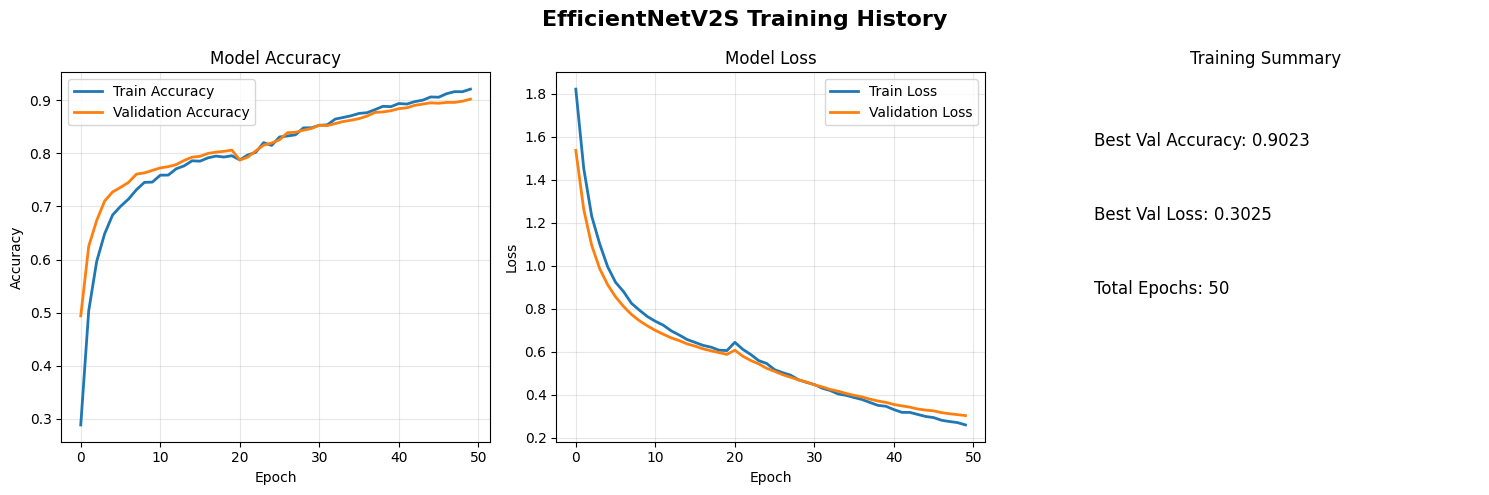

=== EVALUATING EfficientNetV2S MODEL ===
✅ Loaded best saved model
🎯 Test Accuracy: 0.9014
📉 Test Loss: 0.2656

📊 Classification Report:
                     precision    recall  f1-score   support

           Calculus       0.85      0.80      0.82       173
             Caries       0.93      0.78      0.85       189
         Gingivitis       0.77      0.86      0.81       166
            Healthy       0.99      0.98      0.99       181
         Hypodontia       0.94      0.96      0.95       172
Tooth_discoloration       0.87      0.95      0.91       175
             Ulcers       0.96      0.97      0.97       192

           accuracy                           0.90      1248
          macro avg       0.90      0.90      0.90      1248
       weighted avg       0.90      0.90      0.90      1248



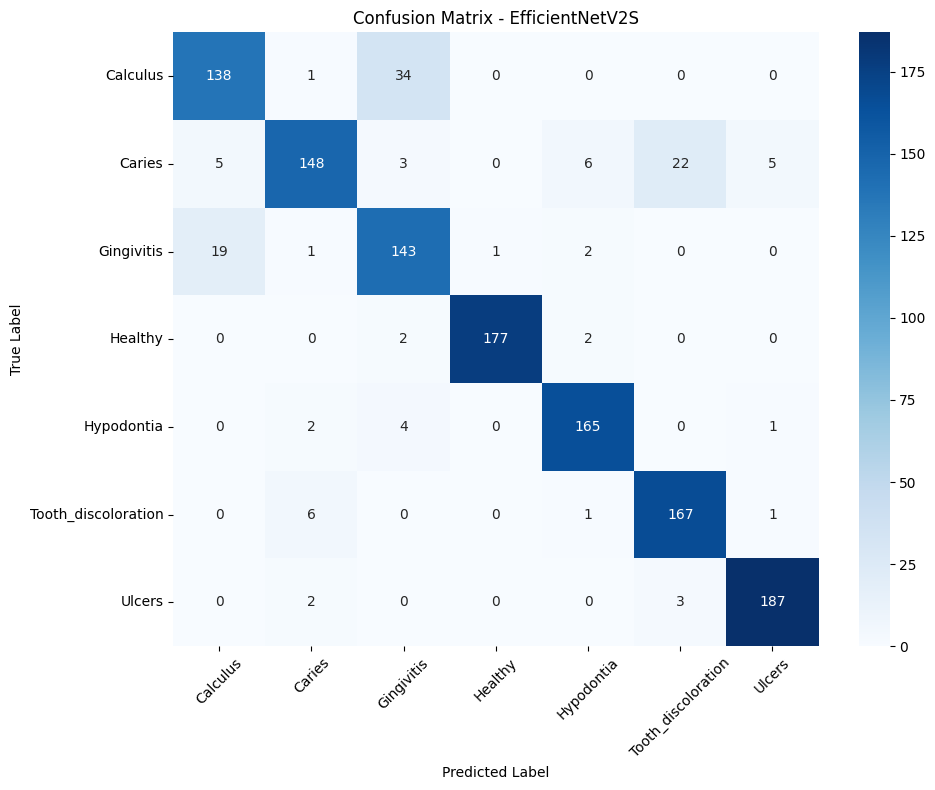

✅ Results saved for EfficientNetV2S
✅ EfficientNetV2-S training completed!


In [ ]:
# ==================== CELL 8: EFFICIENTNETV2-S TRAINING ====================
print("🚀 Starting EfficientNetV2-S Training...")

# Create model-specific preprocessing
def preprocess_efficientnetv2s(image, label):
    image = applications.efficientnet_v2.preprocess_input(image)
    return image, label

# Apply preprocessing
train_ds_eff2s, val_ds_eff2s, test_ds_eff2s = apply_preprocessing(
    train_ds_base, val_ds_base, test_ds_base, data_augmentation, preprocess_efficientnetv2s
)

# Create and train model
model_eff2s, config_eff2s = create_model('EfficientNetV2S')
history_eff2s = train_model(model_eff2s, train_ds_eff2s, val_ds_eff2s, 'EfficientNetV2S')

# Plot training history
plot_training_history(history_eff2s, 'EfficientNetV2S')

# Evaluate model
results_eff2s = evaluate_model(model_eff2s, test_ds_eff2s, 'EfficientNetV2S')

# Save results
save_results('EfficientNetV2S', results_eff2s, history_eff2s)

print("✅ EfficientNetV2-S training completed!")

🚀 Starting ResNet50V2 Training...
✅ Preprocessing applied to all datasets
=== CREATING ResNet50V2 MODEL ===
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ ResNet50V2 model created with 23,579,143 parameters
=== TRAINING ResNet50V2 MODEL ===
🔒 Stage 1: Training with frozen base...
Epoch 1/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1849 - loss: 2.3624
Epoch 1: val_accuracy improved from -inf to 0.43906, saving model to /content/drive/MyDrive/dental_models_comparison/ResNet50V2_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 46s 126ms/step - accuracy: 0.1852 - loss: 2.3610 - val_accuracy: 0.4391 - val_loss: 1.4574 - learning_rate: 1.0000e-04
Epoch 2/20
182/185 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4259 - loss: 1.5330
Epoch 2: val_accuracy improved from 0.43906 to 0.62344, saving model to /content/drive/MyDrive/dental_models_comparison/ResNet50V2_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.4268 - loss: 1.5308 - val_accuracy: 0.6234 - val_loss:

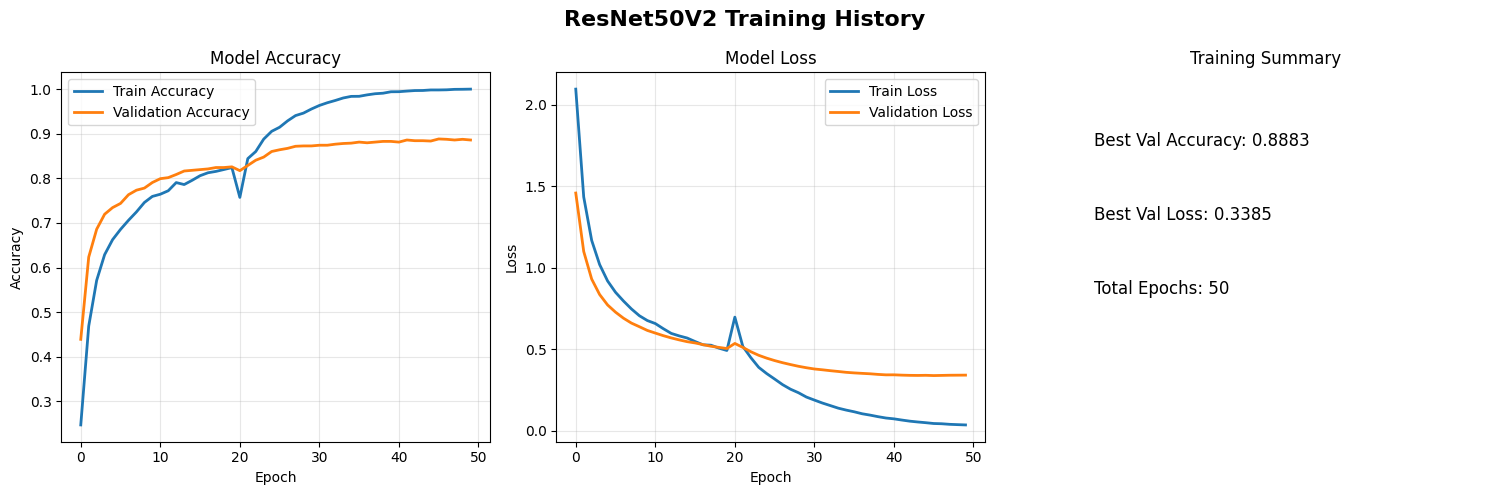

=== EVALUATING ResNet50V2 MODEL ===
✅ Loaded best saved model
🎯 Test Accuracy: 0.8862
📉 Test Loss: 0.3374

📊 Classification Report:
                     precision    recall  f1-score   support

           Calculus       0.80      0.80      0.80       171
             Caries       0.88      0.76      0.82       186
         Gingivitis       0.81      0.84      0.83       167
            Healthy       0.97      0.98      0.97       193
         Hypodontia       0.93      0.96      0.94       166
Tooth_discoloration       0.87      0.90      0.88       174
             Ulcers       0.92      0.95      0.94       191

           accuracy                           0.89      1248
          macro avg       0.88      0.89      0.88      1248
       weighted avg       0.89      0.89      0.89      1248



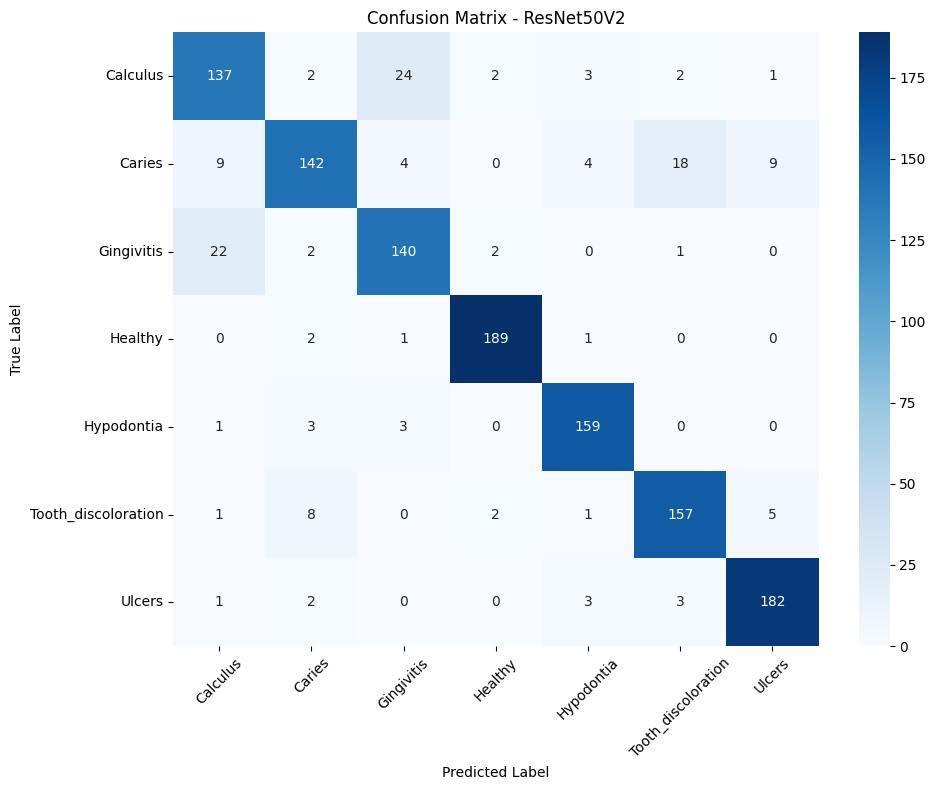

✅ Results saved for ResNet50V2
✅ ResNet50V2 training completed!


In [ ]:
# ==================== CELL 9: RESNET50V2 TRAINING ====================
print("🚀 Starting ResNet50V2 Training...")

# Create model-specific preprocessing
def preprocess_resnet50v2(image, label):
    image = applications.resnet_v2.preprocess_input(image)
    return image, label

# Apply preprocessing
train_ds_resnet, val_ds_resnet, test_ds_resnet = apply_preprocessing(
    train_ds_base, val_ds_base, test_ds_base, data_augmentation, preprocess_resnet50v2
)

# Create and train model
model_resnet, config_resnet = create_model('ResNet50V2')
history_resnet = train_model(model_resnet, train_ds_resnet, val_ds_resnet, 'ResNet50V2')

# Plot training history
plot_training_history(history_resnet, 'ResNet50V2')

# Evaluate model
results_resnet = evaluate_model(model_resnet, test_ds_resnet, 'ResNet50V2')

# Save results
save_results('ResNet50V2', results_resnet, history_resnet)

print("✅ ResNet50V2 training completed!")

🚀 Starting DenseNet121 Training...
✅ Preprocessing applied to all datasets
=== CREATING DenseNet121 MODEL ===
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ DenseNet121 model created with 7,044,679 parameters
=== TRAINING DenseNet121 MODEL ===
🔒 Stage 1: Training with frozen base...
Epoch 1/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.1932 - loss: 2.3055
Epoch 1: val_accuracy improved from -inf to 0.36719, saving model to /content/drive/MyDrive/dental_models_comparison/DenseNet121_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 70s 172ms/step - accuracy: 0.1933 - loss: 2.3047 - val_accuracy: 0.3672 - val_loss: 1.6556 - learning_rate: 1.0000e-04
Epoch 2/20
184/185 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2994 - loss: 1.8342
Epoch 2: val_accuracy improved from 0.36719 to 0.51406, saving model to /content/drive/MyDrive/dental_models_comparison/DenseNet121_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.2996 - loss: 1.8336 - val_accuracy: 0.5141 - val_

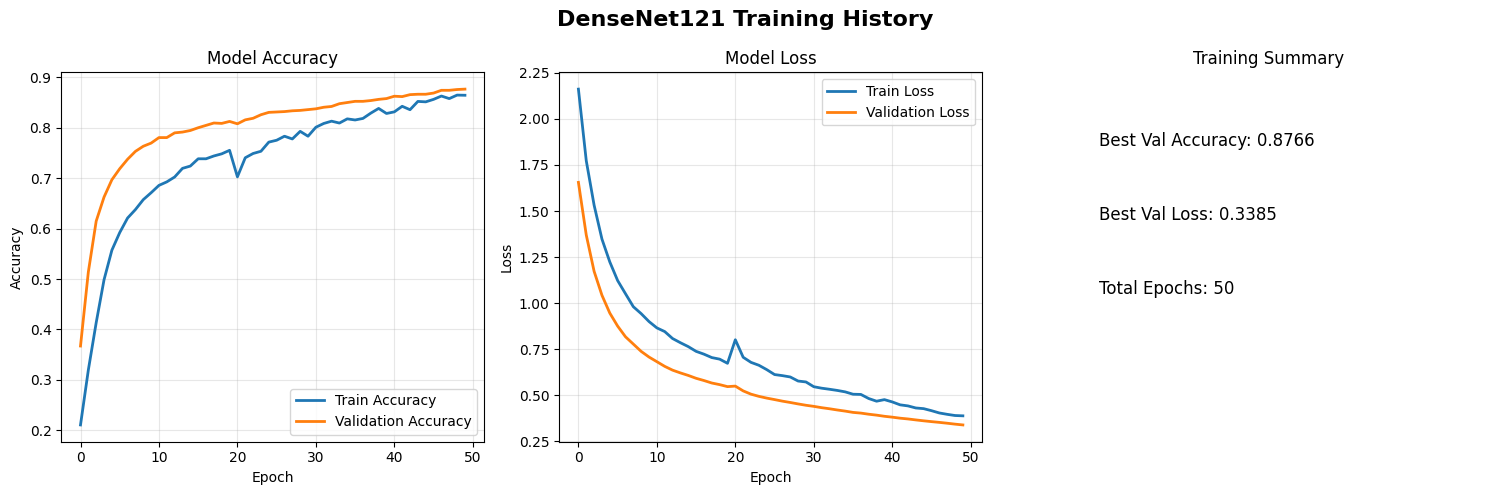

=== EVALUATING DenseNet121 MODEL ===
✅ Loaded best saved model
🎯 Test Accuracy: 0.8638
📉 Test Loss: 0.3401

📊 Classification Report:
                     precision    recall  f1-score   support

           Calculus       0.75      0.75      0.75       168
             Caries       0.86      0.79      0.82       198
         Gingivitis       0.71      0.78      0.74       164
            Healthy       0.99      0.96      0.98       192
         Hypodontia       0.91      0.94      0.93       170
Tooth_discoloration       0.89      0.86      0.87       176
             Ulcers       0.92      0.96      0.94       180

           accuracy                           0.86      1248
          macro avg       0.86      0.86      0.86      1248
       weighted avg       0.87      0.86      0.86      1248



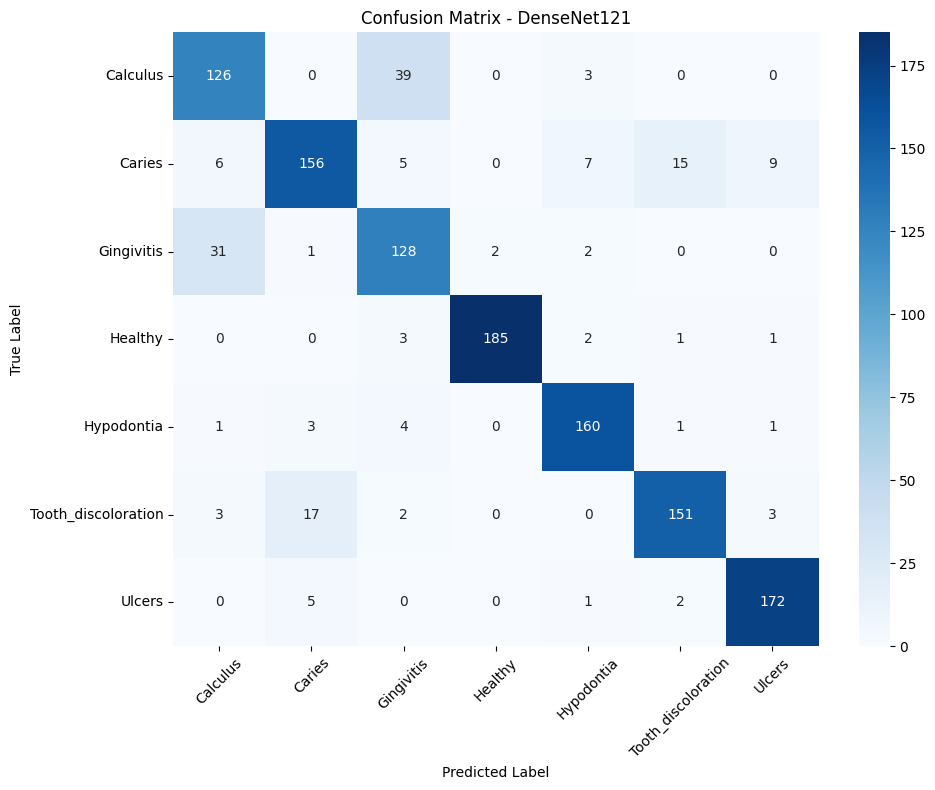

✅ Results saved for DenseNet121
✅ DenseNet121 training completed!


In [ ]:
# ==================== CELL 10: DENSENET121 TRAINING ====================
print("🚀 Starting DenseNet121 Training...")

# Create model-specific preprocessing
def preprocess_densenet121(image, label):
    image = applications.densenet.preprocess_input(image)
    return image, label

# Apply preprocessing
train_ds_dense121, val_ds_dense121, test_ds_dense121 = apply_preprocessing(
    train_ds_base, val_ds_base, test_ds_base, data_augmentation, preprocess_densenet121
)

# Create and train model
model_dense121, config_dense121 = create_model('DenseNet121')
history_dense121 = train_model(model_dense121, train_ds_dense121, val_ds_dense121, 'DenseNet121')

# Plot training history
plot_training_history(history_dense121, 'DenseNet121')

# Evaluate model
results_dense121 = evaluate_model(model_dense121, test_ds_dense121, 'DenseNet121')

# Save results
save_results('DenseNet121', results_dense121, history_dense121)

print("✅ DenseNet121 training completed!")

🚀 Starting DenseNet201 Training...
✅ Preprocessing applied to all datasets
=== CREATING DenseNet201 MODEL ===
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ DenseNet201 model created with 18,335,431 parameters
=== TRAINING DenseNet201 MODEL ===
🔒 Stage 1: Training with frozen base...
Epoch 1/20
184/185 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.1881 - loss: 2.1676
Epoch 1: val_accuracy improved from -inf to 0.42578, saving model to /content/drive/MyDrive/dental_models_comparison/DenseNet201_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 105s 279ms/step - accuracy: 0.1885 - loss: 2.1658 - val_accuracy: 0.4258 - val_loss: 1.5634 - learning_rate: 1.0000e-04
Epoch 2/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4056 - loss: 1.5954
Epoch 2: val_accuracy improved from 0.42578 to 0.60547, saving model to /content/drive/MyDrive/dental_models_comparison/DenseNet201_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.4057 - loss: 1.5950 - val_accuracy: 0.6055 - v

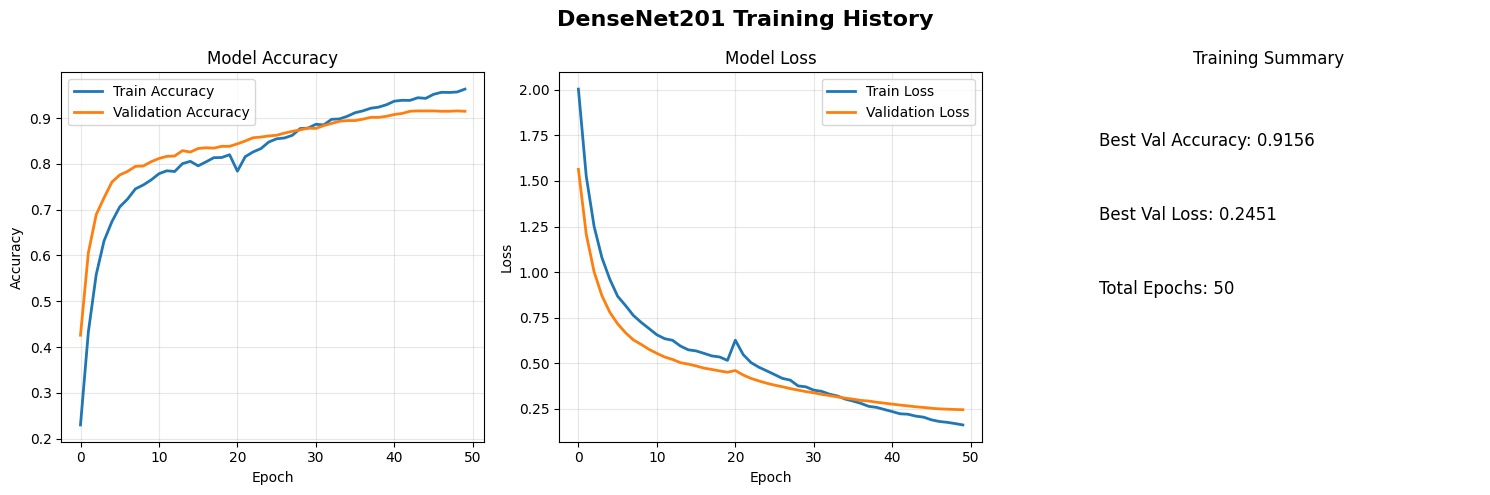

=== EVALUATING DenseNet201 MODEL ===
✅ Loaded best saved model
🎯 Test Accuracy: 0.9167
📉 Test Loss: 0.2510

📊 Classification Report:
                     precision    recall  f1-score   support

           Calculus       0.83      0.85      0.84       178
             Caries       0.96      0.80      0.87       189
         Gingivitis       0.80      0.84      0.82       160
            Healthy       1.00      0.98      0.99       195
         Hypodontia       0.95      0.96      0.95       167
Tooth_discoloration       0.91      0.98      0.95       167
             Ulcers       0.96      0.99      0.98       192

           accuracy                           0.92      1248
          macro avg       0.92      0.92      0.91      1248
       weighted avg       0.92      0.92      0.92      1248



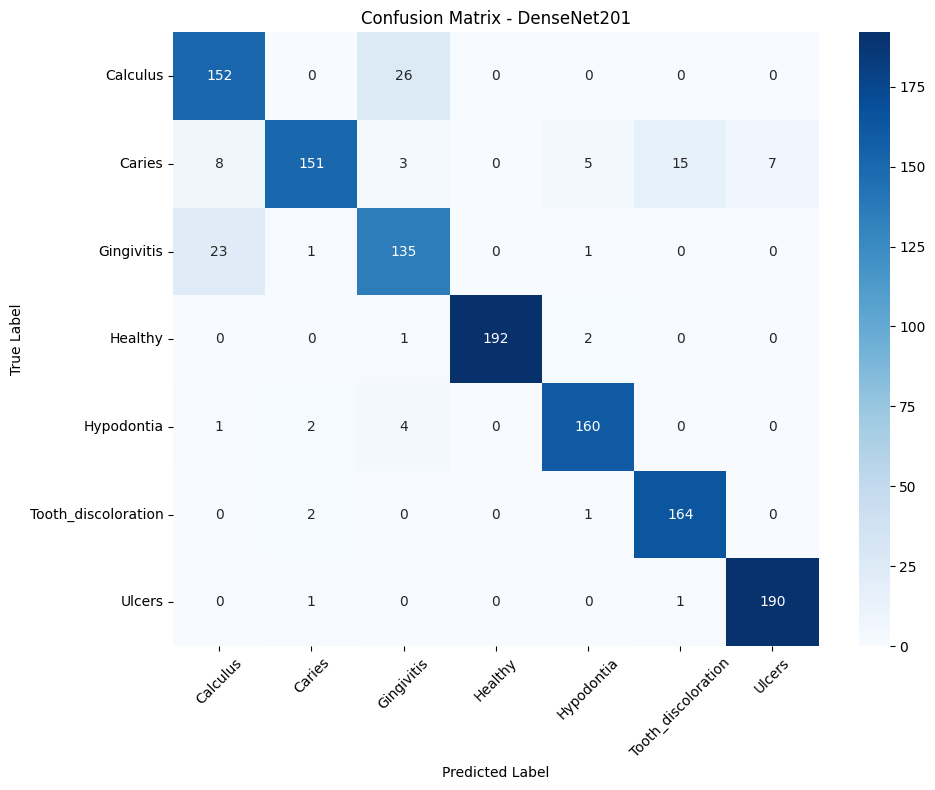

✅ Results saved for DenseNet201
✅ DenseNet201 training completed!


In [ ]:
# ==================== CELL 11: DENSENET201 TRAINING ====================
print("🚀 Starting DenseNet201 Training...")

# Create model-specific preprocessing
def preprocess_densenet201(image, label):
    image = applications.densenet.preprocess_input(image)
    return image, label

# Apply preprocessing
train_ds_dense201, val_ds_dense201, test_ds_dense201 = apply_preprocessing(
    train_ds_base, val_ds_base, test_ds_base, data_augmentation, preprocess_densenet201
)

# Create and train model
model_dense201, config_dense201 = create_model('DenseNet201')
history_dense201 = train_model(model_dense201, train_ds_dense201, val_ds_dense201, 'DenseNet201')

# Plot training history
plot_training_history(history_dense201, 'DenseNet201')

# Evaluate model
results_dense201 = evaluate_model(model_dense201, test_ds_dense201, 'DenseNet201')

# Save results
save_results('DenseNet201', results_dense201, history_dense201)

print("✅ DenseNet201 training completed!")

🚀 Starting InceptionV3 Training...
✅ Preprocessing applied to all datasets
=== CREATING InceptionV3 MODEL ===
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ InceptionV3 model created with 21,817,127 parameters
=== TRAINING InceptionV3 MODEL ===
🔒 Stage 1: Training with frozen base...
Epoch 1/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.2077 - loss: 2.2726
Epoch 1: val_accuracy improved from -inf to 0.45859, saving model to /content/drive/MyDrive/dental_models_comparison/InceptionV3_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 50s 123ms/step - accuracy: 0.2081 - loss: 2.2711 - val_accuracy: 0.4586 - val_loss: 1.4374 - learning_rate: 1.0000e-04
Epoch 2/20
182/185 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4466 - loss: 1.4880
Epoch 2: val_accuracy improved from 0.45859 to 0.57656, saving model to /content/drive/MyDrive/dental_models_comparison/InceptionV3_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.4472 - loss: 1.4866 - val_accuracy: 0.5766 - val

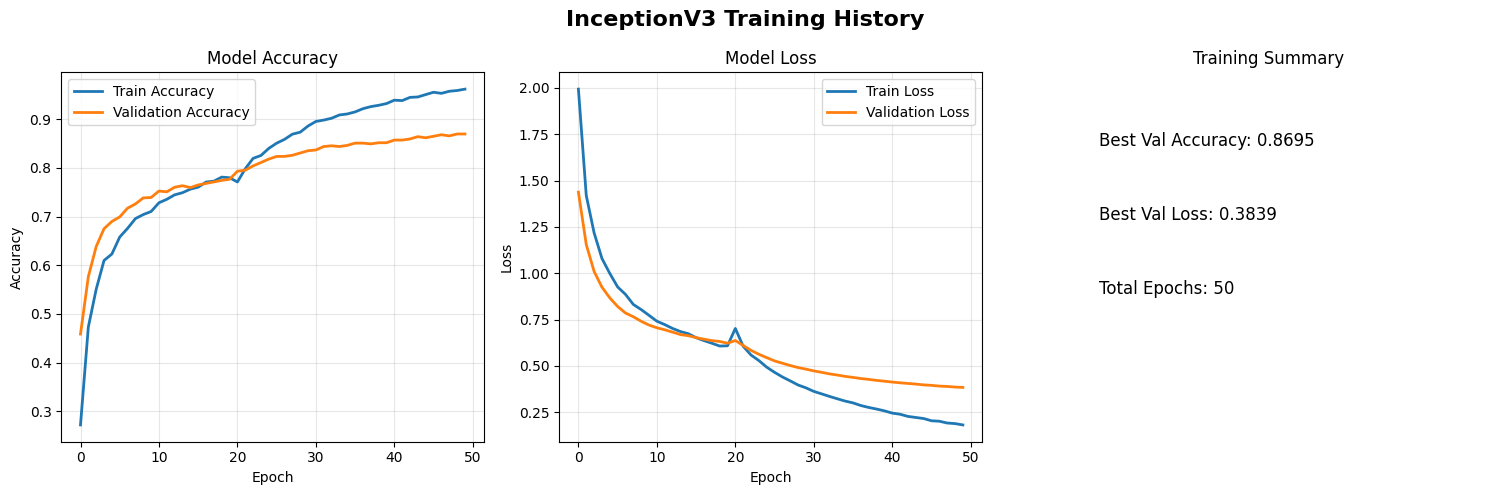

=== EVALUATING InceptionV3 MODEL ===
✅ Loaded best saved model
🎯 Test Accuracy: 0.8534
📉 Test Loss: 0.3739

📊 Classification Report:
                     precision    recall  f1-score   support

           Calculus       0.77      0.73      0.75       165
             Caries       0.87      0.71      0.78       194
         Gingivitis       0.71      0.80      0.75       167
            Healthy       0.97      0.95      0.96       191
         Hypodontia       0.92      0.94      0.93       169
Tooth_discoloration       0.82      0.88      0.85       171
             Ulcers       0.90      0.95      0.92       191

           accuracy                           0.85      1248
          macro avg       0.85      0.85      0.85      1248
       weighted avg       0.86      0.85      0.85      1248



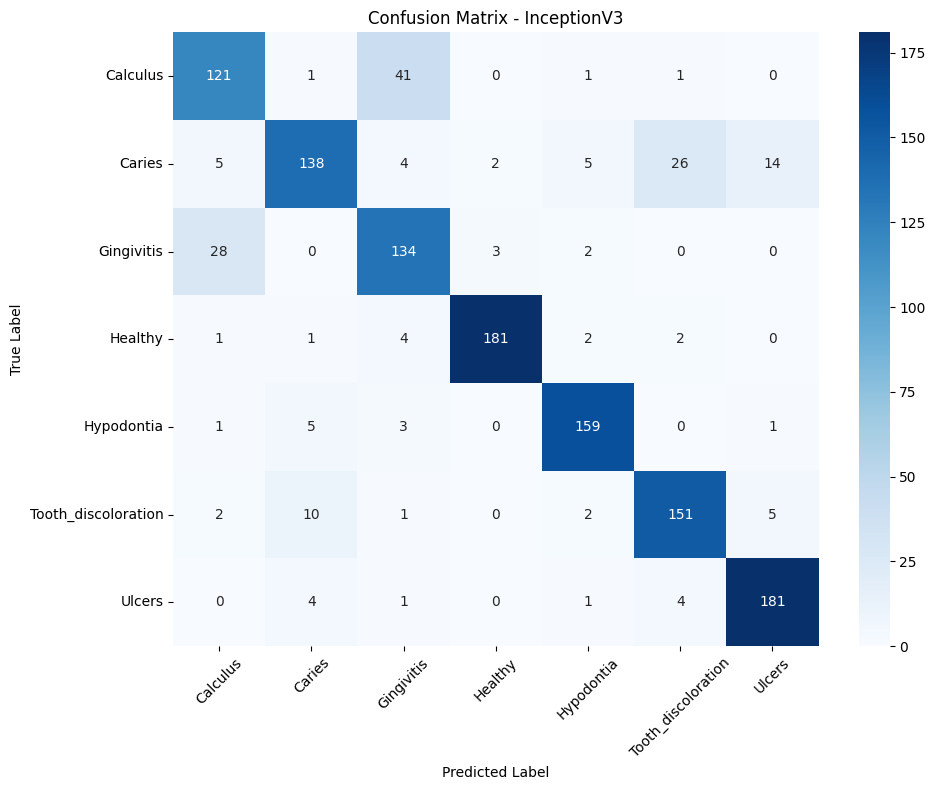

✅ Results saved for InceptionV3
✅ InceptionV3 training completed!


In [ ]:
# ==================== CELL 12: INCEPTIONV3 TRAINING ====================
print("🚀 Starting InceptionV3 Training...")

# Create model-specific preprocessing
def preprocess_inceptionv3(image, label):
    image = applications.inception_v3.preprocess_input(image)
    return image, label

# Apply preprocessing
train_ds_inception, val_ds_inception, test_ds_inception = apply_preprocessing(
    train_ds_base, val_ds_base, test_ds_base, data_augmentation, preprocess_inceptionv3
)

# Create and train model
model_inception, config_inception = create_model('InceptionV3')
history_inception = train_model(model_inception, train_ds_inception, val_ds_inception, 'InceptionV3')

# Plot training history
plot_training_history(history_inception, 'InceptionV3')

# Evaluate model
results_inception = evaluate_model(model_inception, test_ds_inception, 'InceptionV3')

# Save results
save_results('InceptionV3', results_inception, history_inception)

print("✅ InceptionV3 training completed!")

🚀 Starting VGG16 Training...
✅ Preprocessing applied to all datasets
=== CREATING VGG16 MODEL ===
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ VGG16 model created with 14,718,279 parameters
=== TRAINING VGG16 MODEL ===
🔒 Stage 1: Training with frozen base...
Epoch 1/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1587 - loss: 8.5442
Epoch 1: val_accuracy improved from -inf to 0.21797, saving model to /content/drive/MyDrive/dental_models_comparison/VGG16_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 34s 88ms/step - accuracy: 0.1588 - loss: 8.5386 - val_accuracy: 0.2180 - val_loss: 4.7667 - learning_rate: 1.0000e-04
Epoch 2/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1930 - loss: 6.0617
Epoch 2: val_accuracy improved from 0.21797 to 0.31484, saving model to /content/drive/MyDrive/dental_models_comparison/VGG16_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.1930 - loss: 6.0602 - val_accuracy: 0.3148 - val_loss: 3.5642 - learning_rate: 1.0000

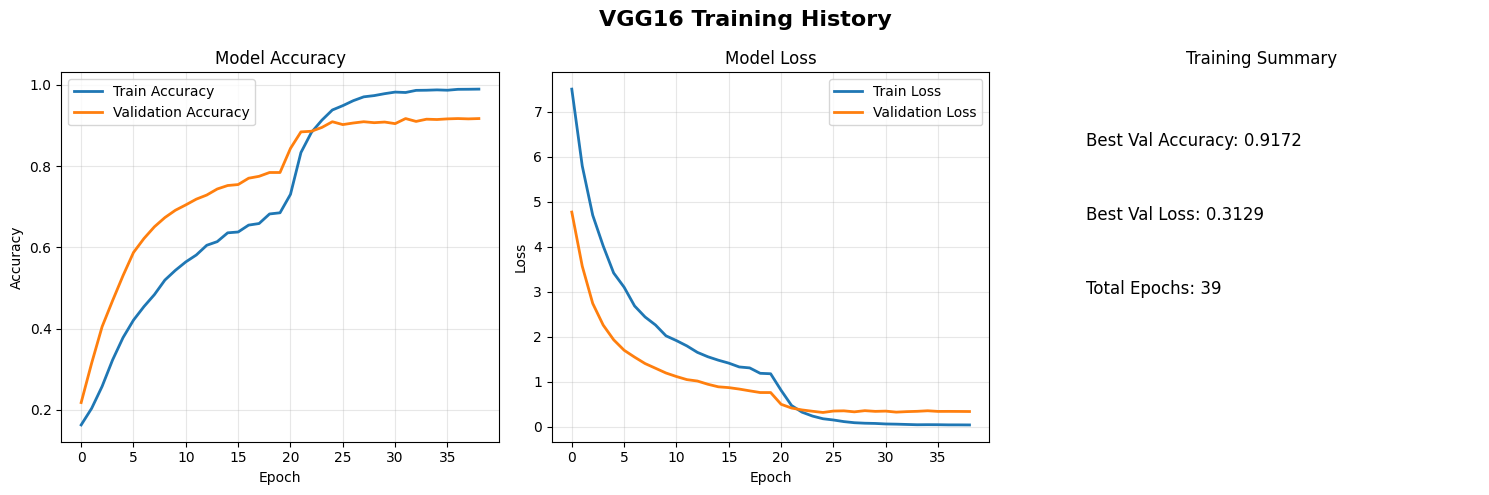

=== EVALUATING VGG16 MODEL ===
✅ Loaded best saved model
🎯 Test Accuracy: 0.9239
📉 Test Loss: 0.2568

📊 Classification Report:
                     precision    recall  f1-score   support

           Calculus       0.86      0.85      0.85       179
             Caries       0.93      0.87      0.90       196
         Gingivitis       0.80      0.87      0.83       165
            Healthy       0.99      0.97      0.98       192
         Hypodontia       0.96      0.96      0.96       164
Tooth_discoloration       0.94      0.96      0.95       170
             Ulcers       0.98      0.99      0.99       182

           accuracy                           0.92      1248
          macro avg       0.92      0.92      0.92      1248
       weighted avg       0.93      0.92      0.92      1248



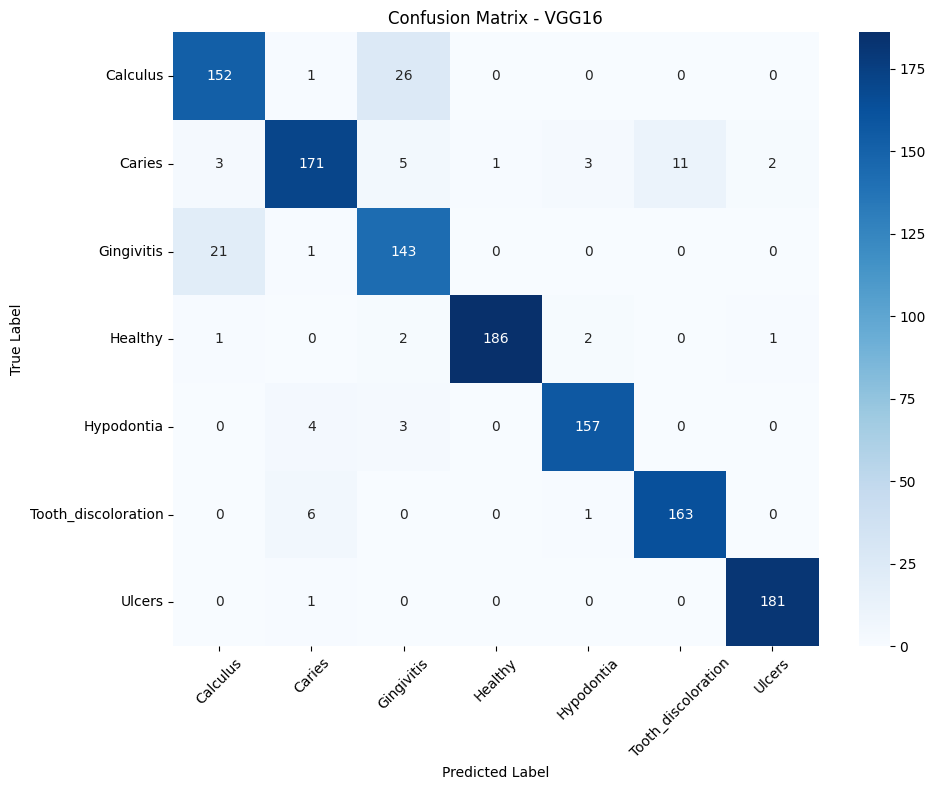

✅ Results saved for VGG16
✅ VGG16 training completed!


In [ ]:
# ==================== CELL 13: VGG16 TRAINING ====================
print("🚀 Starting VGG16 Training...")

# Create model-specific preprocessing
def preprocess_vgg16(image, label):
    image = applications.vgg16.preprocess_input(image)
    return image, label

# Apply preprocessing
train_ds_vgg16, val_ds_vgg16, test_ds_vgg16 = apply_preprocessing(
    train_ds_base, val_ds_base, test_ds_base, data_augmentation, preprocess_vgg16
)

# Create and train model
model_vgg16, config_vgg16 = create_model('VGG16')
history_vgg16 = train_model(model_vgg16, train_ds_vgg16, val_ds_vgg16, 'VGG16')

# Plot training history
plot_training_history(history_vgg16, 'VGG16')

# Evaluate model
results_vgg16 = evaluate_model(model_vgg16, test_ds_vgg16, 'VGG16')

# Save results
save_results('VGG16', results_vgg16, history_vgg16)

print("✅ VGG16 training completed!")

🚀 Starting EfficientNetB0 Training...
✅ Preprocessing applied to all datasets
=== CREATING EfficientNetB0 MODEL ===
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ EfficientNetB0 model created with 4,058,538 parameters
=== TRAINING EfficientNetB0 MODEL ===
🔒 Stage 1: Training with frozen base...
Epoch 1/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.2065 - loss: 1.9784
Epoch 1: val_accuracy improved from -inf to 0.48750, saving model to /content/drive/MyDrive/dental_models_comparison/EfficientNetB0_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 68s 159ms/step - accuracy: 0.2069 - loss: 1.9776 - val_accuracy: 0.4875 - val_loss: 1.5119 - learning_rate: 1.0000e-04
Epoch 2/20
182/185 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4947 - loss: 1.4646
Epoch 2: val_accuracy improved from 0.48750 to 0.63984, saving model to /content/drive/MyDrive/dental_models_comparison/EfficientNetB0_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.4951 - loss: 1.4634 - val_accur

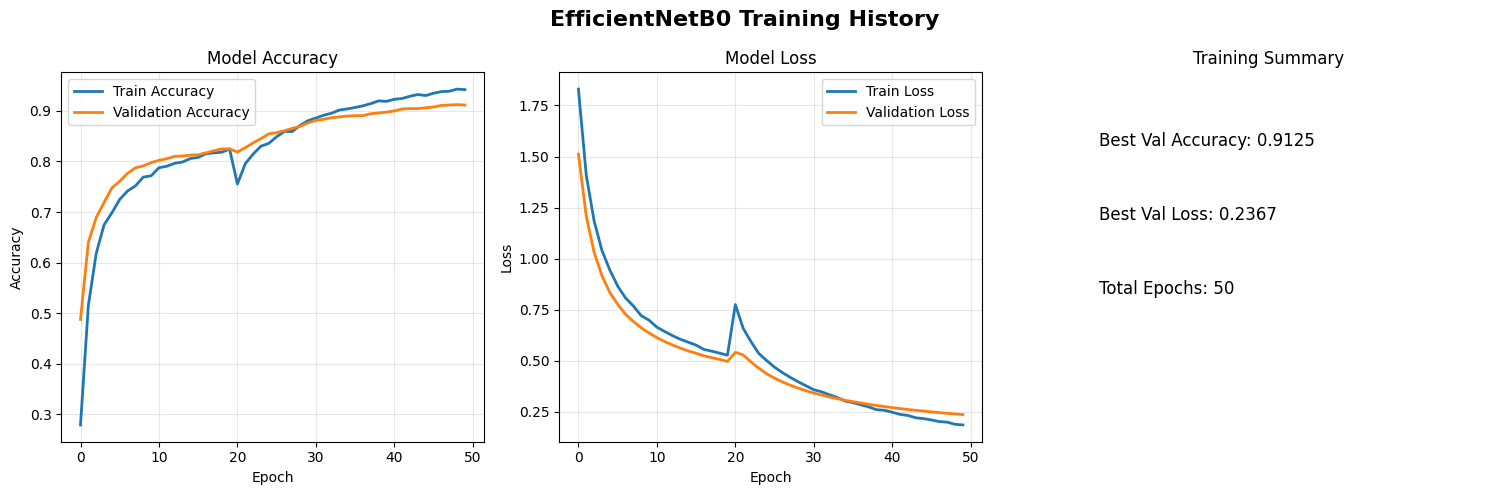

=== EVALUATING EfficientNetB0 MODEL ===
✅ Loaded best saved model
🎯 Test Accuracy: 0.9311
📉 Test Loss: 0.2092

📊 Classification Report:
                     precision    recall  f1-score   support

           Calculus       0.88      0.87      0.87       172
             Caries       0.93      0.84      0.88       194
         Gingivitis       0.85      0.90      0.87       159
            Healthy       0.99      0.99      0.99       189
         Hypodontia       0.96      0.99      0.97       177
Tooth_discoloration       0.92      0.94      0.93       174
             Ulcers       0.97      0.99      0.98       183

           accuracy                           0.93      1248
          macro avg       0.93      0.93      0.93      1248
       weighted avg       0.93      0.93      0.93      1248



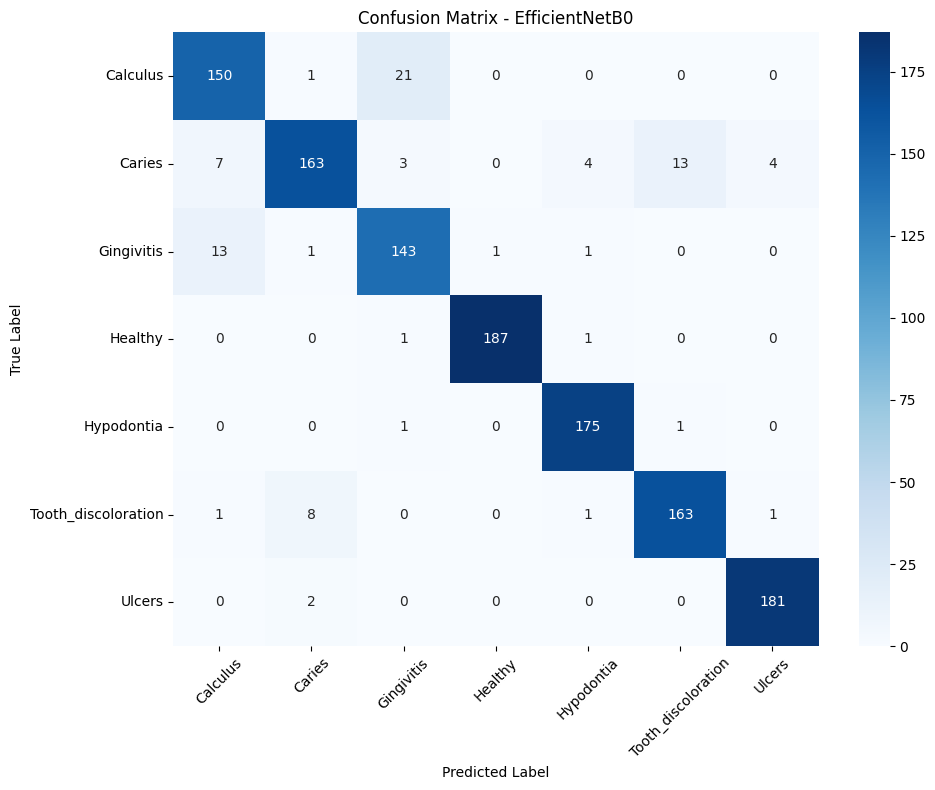

✅ Results saved for EfficientNetB0
✅ EfficientNetB0 training completed!


In [ ]:
# ==================== CELL 14: EFFICIENTNETB0 TRAINING ====================
print("🚀 Starting EfficientNetB0 Training...")

# Create model-specific preprocessing
def preprocess_efficientnetb0(image, label):
    image = applications.efficientnet.preprocess_input(image)
    return image, label

# Apply preprocessing
train_ds_effb0, val_ds_effb0, test_ds_effb0 = apply_preprocessing(
    train_ds_base, val_ds_base, test_ds_base, data_augmentation, preprocess_efficientnetb0
)

# Create and train model
model_effb0, config_effb0 = create_model('EfficientNetB0')
history_effb0 = train_model(model_effb0, train_ds_effb0, val_ds_effb0, 'EfficientNetB0')

# Plot training history
plot_training_history(history_effb0, 'EfficientNetB0')

# Evaluate model
results_effb0 = evaluate_model(model_effb0, test_ds_effb0, 'EfficientNetB0')

# Save results
save_results('EfficientNetB0', results_effb0, history_effb0)

print("✅ EfficientNetB0 training completed!")

🚀 Starting EfficientNetB3 Training...
✅ Preprocessing applied to all datasets
=== CREATING EfficientNetB3 MODEL ===
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ EfficientNetB3 model created with 10,794,294 parameters
=== TRAINING EfficientNetB3 MODEL ===
🔒 Stage 1: Training with frozen base...
Epoch 1/20
183/185 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.2153 - loss: 1.9313
Epoch 1: val_accuracy improved from -inf to 0.52422, saving model to /content/drive/MyDrive/dental_models_comparison/EfficientNetB3_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 104s 248ms/step - accuracy: 0.2167 - loss: 1.9287 - val_accuracy: 0.5242 - val_loss: 1.4362 - learning_rate: 1.0000e-04
Epoch 2/20
184/185 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4958 - loss: 1.4381
Epoch 2: val_accuracy improved from 0.52422 to 0.64766, saving model to /content/drive/MyDrive/dental_models_comparison/EfficientNetB3_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.4962 - loss: 1.4373 - val_ac

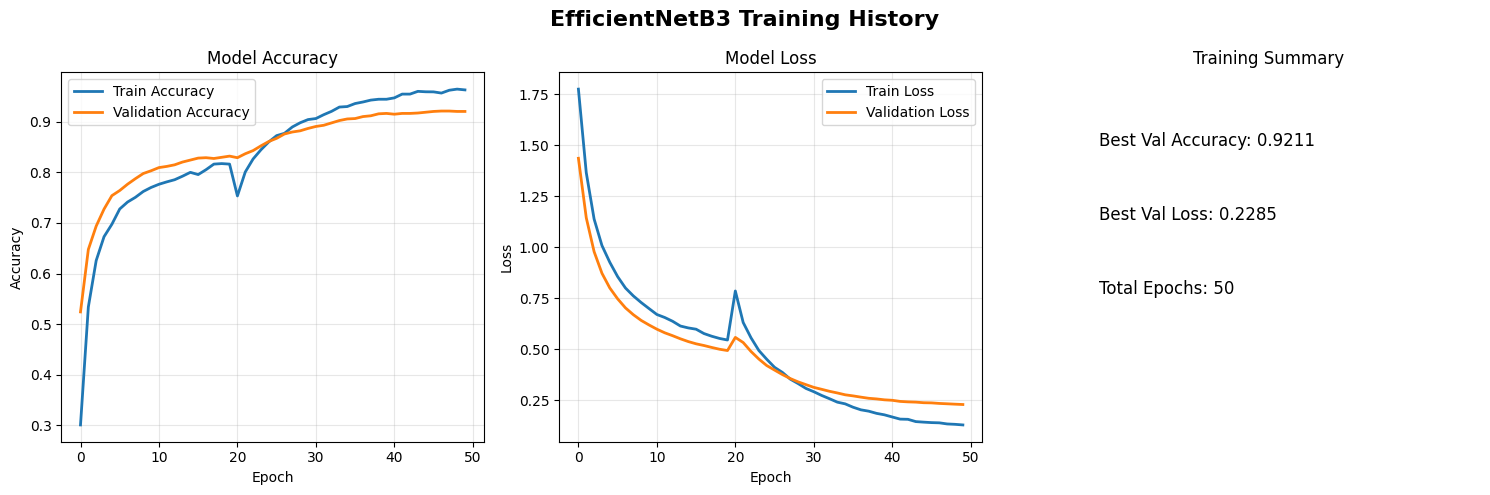

=== EVALUATING EfficientNetB3 MODEL ===
✅ Loaded best saved model
🎯 Test Accuracy: 0.9191
📉 Test Loss: 0.2258

📊 Classification Report:
                     precision    recall  f1-score   support

           Calculus       0.85      0.85      0.85       169
             Caries       0.96      0.81      0.88       194
         Gingivitis       0.80      0.88      0.84       167
            Healthy       0.99      0.99      0.99       191
         Hypodontia       0.96      0.97      0.96       168
Tooth_discoloration       0.89      0.95      0.92       170
             Ulcers       0.98      0.98      0.98       189

           accuracy                           0.92      1248
          macro avg       0.92      0.92      0.92      1248
       weighted avg       0.92      0.92      0.92      1248



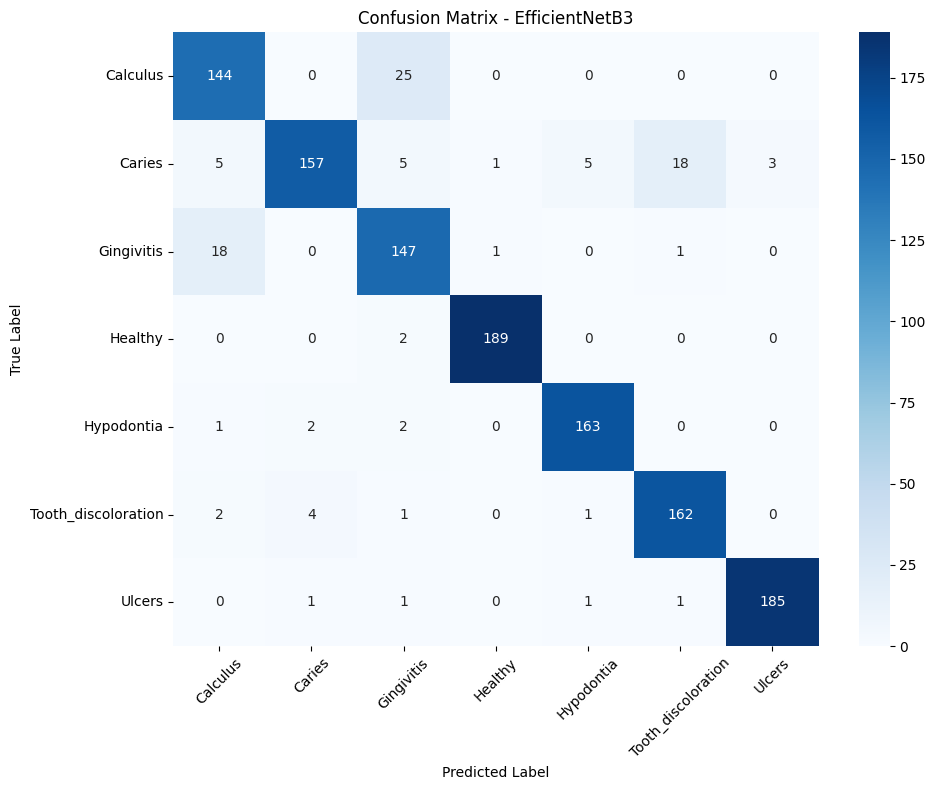

✅ Results saved for EfficientNetB3
✅ EfficientNetB3 training completed!


In [ ]:
# ==================== CELL 15: EFFICIENTNETB3 TRAINING ====================
print("🚀 Starting EfficientNetB3 Training...")

# Create model-specific preprocessing
def preprocess_efficientnetb3(image, label):
    image = applications.efficientnet.preprocess_input(image)
    return image, label

# Apply preprocessing
train_ds_effb3, val_ds_effb3, test_ds_effb3 = apply_preprocessing(
    train_ds_base, val_ds_base, test_ds_base, data_augmentation, preprocess_efficientnetb3
)

# Create and train model
model_effb3, config_effb3 = create_model('EfficientNetB3')
history_effb3 = train_model(model_effb3, train_ds_effb3, val_ds_effb3, 'EfficientNetB3')

# Plot training history
plot_training_history(history_effb3, 'EfficientNetB3')

# Evaluate model
results_effb3 = evaluate_model(model_effb3, test_ds_effb3, 'EfficientNetB3')

# Save results
save_results('EfficientNetB3', results_effb3, history_effb3)

print("✅ EfficientNetB3 training completed!")

🚀 Starting MobileNetV2 Training...
✅ Preprocessing applied to all datasets
=== CREATING MobileNetV2 MODEL ===
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ MobileNetV2 model created with 2,266,951 parameters
=== TRAINING MobileNetV2 MODEL ===
🔒 Stage 1: Training with frozen base...
Epoch 1/20
183/185 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1946 - loss: 2.2842
Epoch 1: val_accuracy improved from -inf to 0.50078, saving model to /content/drive/MyDrive/dental_models_comparison/MobileNetV2_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 38s 83ms/step - accuracy: 0.1954 - loss: 2.2803 - val_accuracy: 0.5008 - val_loss: 1.4290 - learning_rate: 1.0000e-04
Epoch 2/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3995 - loss: 1.5764
Epoch 2: val_accuracy improved from 0.50078 to 0.66172, saving model to /content/drive/MyDrive/dental_models_comparison/MobileNetV2_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3998 - loss: 1.5758 - val_accuracy: 0.6617 - val_los

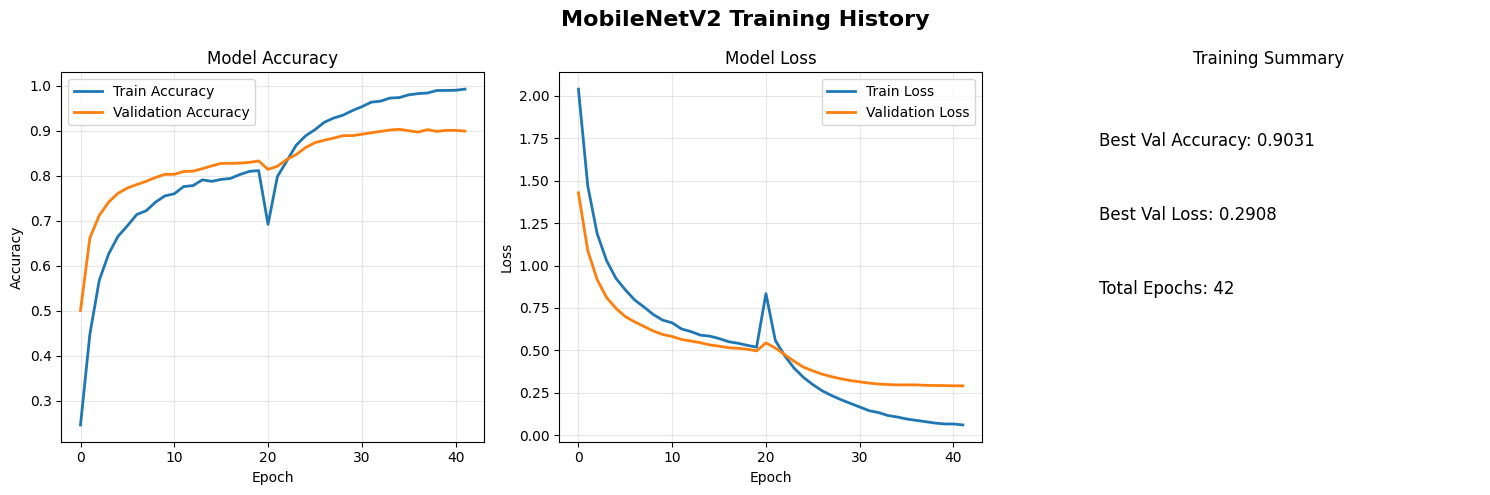

=== EVALUATING MobileNetV2 MODEL ===
✅ Loaded best saved model
🎯 Test Accuracy: 0.9054
📉 Test Loss: 0.2429

📊 Classification Report:
                     precision    recall  f1-score   support

           Calculus       0.82      0.83      0.82       180
             Caries       0.88      0.87      0.87       189
         Gingivitis       0.79      0.83      0.81       161
            Healthy       0.97      0.97      0.97       191
         Hypodontia       0.97      0.96      0.96       166
Tooth_discoloration       0.94      0.91      0.92       173
             Ulcers       0.97      0.97      0.97       188

           accuracy                           0.91      1248
          macro avg       0.91      0.90      0.90      1248
       weighted avg       0.91      0.91      0.91      1248



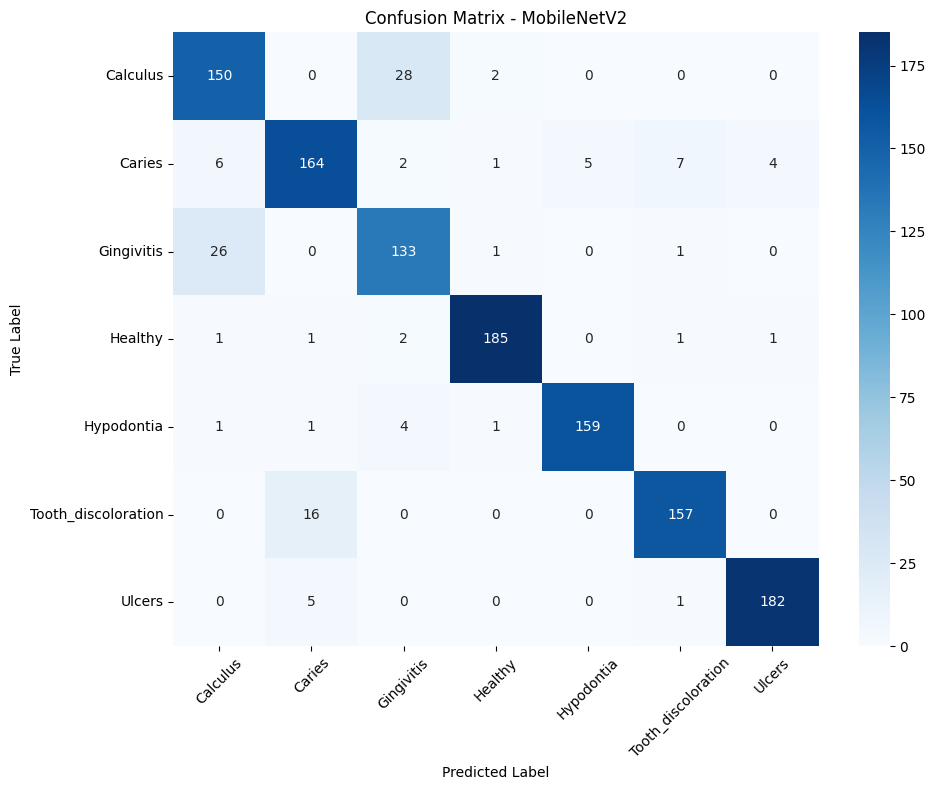

✅ Results saved for MobileNetV2
✅ MobileNetV2 training completed!


In [ ]:
# ==================== CELL 16: MOBILENETV2 TRAINING ====================
print("🚀 Starting MobileNetV2 Training...")

# Create model-specific preprocessing
def preprocess_mobilenetv2(image, label):
    image = applications.mobilenet_v2.preprocess_input(image)
    return image, label

# Apply preprocessing
train_ds_mobile, val_ds_mobile, test_ds_mobile = apply_preprocessing(
    train_ds_base, val_ds_base, test_ds_base, data_augmentation, preprocess_mobilenetv2
)

# Create and train model
model_mobile, config_mobile = create_model('MobileNetV2')
history_mobile = train_model(model_mobile, train_ds_mobile, val_ds_mobile, 'MobileNetV2')

# Plot training history
plot_training_history(history_mobile, 'MobileNetV2')

# Evaluate model
results_mobile = evaluate_model(model_mobile, test_ds_mobile, 'MobileNetV2')

# Save results
save_results('MobileNetV2', results_mobile, history_mobile)

print("✅ MobileNetV2 training completed!")

🚀 Starting ConvNeXt-Tiny Training...
✅ Preprocessing applied to all datasets
=== CREATING ConvNeXt-Tiny MODEL ===
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ ConvNeXt-Tiny model created with 27,825,511 parameters
=== TRAINING ConvNeXt-Tiny MODEL ===
🔒 Stage 1: Training with frozen base...
Epoch 1/20
183/185 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.1811 - loss: 2.0565
Epoch 1: val_accuracy improved from -inf to 0.42578, saving model to /content/drive/MyDrive/dental_models_comparison/ConvNeXt-Tiny_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 70s 183ms/step - accuracy: 0.1818 - loss: 2.0545 - val_accuracy: 0.4258 - val_loss: 1.6286 - learning_rate: 1.0000e-04
Epoch 2/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3768 - loss: 1.6526
Epoch 2: val_accuracy improved from 0.42578 to 0.55703, saving model to /content/drive/MyDrive/dental_models_comparison/ConvNeXt-Tiny_best.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.3771 - loss: 1.6522 - val_accuracy

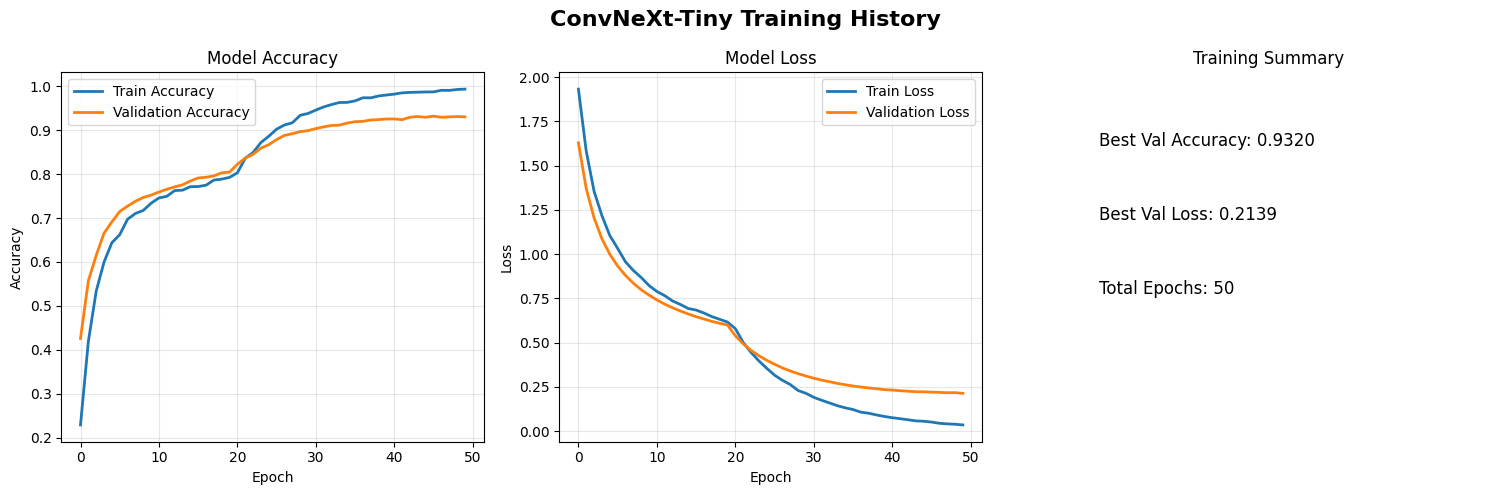

=== EVALUATING ConvNeXt-Tiny MODEL ===
✅ Loaded best saved model
🎯 Test Accuracy: 0.9383
📉 Test Loss: 0.1829

📊 Classification Report:
                     precision    recall  f1-score   support

           Calculus       0.84      0.88      0.86       174
             Caries       0.97      0.91      0.94       197
         Gingivitis       0.85      0.85      0.85       170
            Healthy       0.99      0.98      0.99       188
         Hypodontia       0.98      0.98      0.98       167
Tooth_discoloration       0.95      0.98      0.96       168
             Ulcers       0.99      0.99      0.99       184

           accuracy                           0.94      1248
          macro avg       0.94      0.94      0.94      1248
       weighted avg       0.94      0.94      0.94      1248



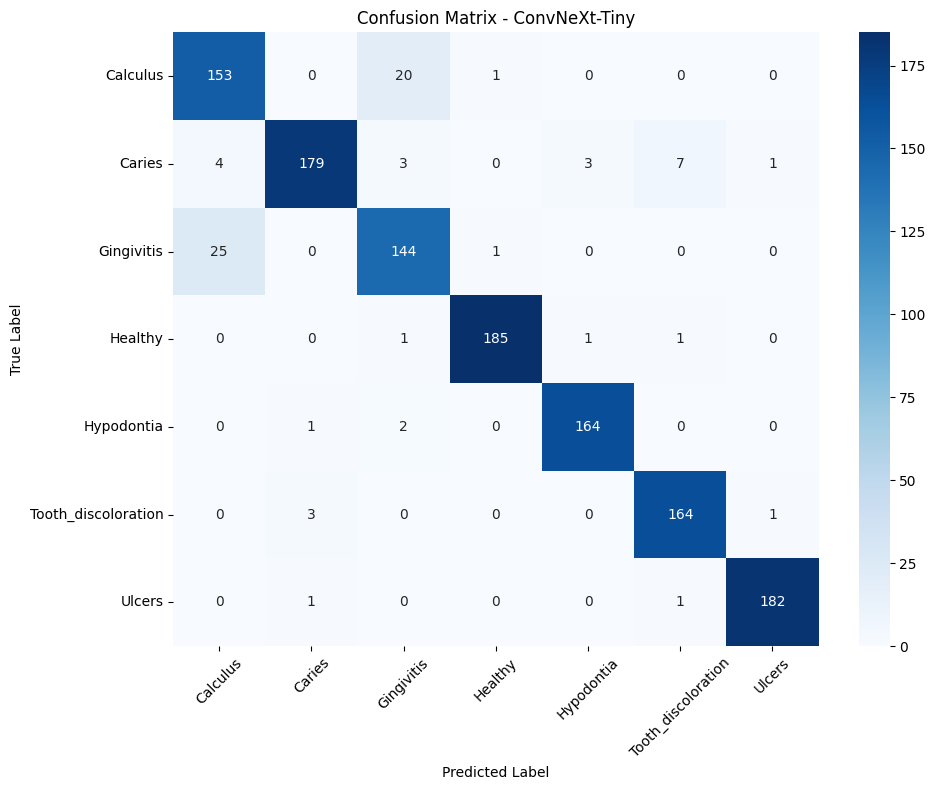

✅ Results saved for ConvNeXt-Tiny
✅ ConvNeXt-Tiny training completed!


In [ ]:
# ==================== CELL 17: CONVNEXT-TINY TRAINING ====================
print("🚀 Starting ConvNeXt-Tiny Training...")

# Create model-specific preprocessing
def preprocess_convnext(image, label):
    image = applications.convnext.preprocess_input(image)
    return image, label

# Apply preprocessing
train_ds_convnext, val_ds_convnext, test_ds_convnext = apply_preprocessing(
    train_ds_base, val_ds_base, test_ds_base, data_augmentation, preprocess_convnext
)

# Create and train model
model_convnext, config_convnext = create_model('ConvNeXt-Tiny')
history_convnext = train_model(model_convnext, train_ds_convnext, val_ds_convnext, 'ConvNeXt-Tiny')

# Plot training history
plot_training_history(history_convnext, 'ConvNeXt-Tiny')

# Evaluate model
results_convnext = evaluate_model(model_convnext, test_ds_convnext, 'ConvNeXt-Tiny')

# Save results
save_results('ConvNeXt-Tiny', results_convnext, history_convnext)

print("✅ ConvNeXt-Tiny training completed!")

=== COMPREHENSIVE MODEL COMPARISON ===

📊 MODEL COMPARISON SUMMARY:
          Model  Test Accuracy  Test Loss  Best Val Accuracy  Best Val Loss  Training Epochs  Precision (Macro)  Recall (Macro)  F1-Score (Macro)
  ConvNeXt-Tiny         0.9383     0.1829             0.9320         0.2139               50             0.9376          0.9381            0.9376
 EfficientNetB0         0.9311     0.2092             0.9125         0.2367               50             0.9293          0.9308            0.9295
          VGG16         0.9239     0.2568             0.9172         0.3129               39             0.9236          0.9240            0.9234
 EfficientNetB3         0.9191     0.2258             0.9211         0.2285               50             0.9186          0.9190            0.9175
    DenseNet201         0.9167     0.2510             0.9156         0.2451               50             0.9156          0.9158            0.9143
    MobileNetV2         0.9054     0.2429             0.

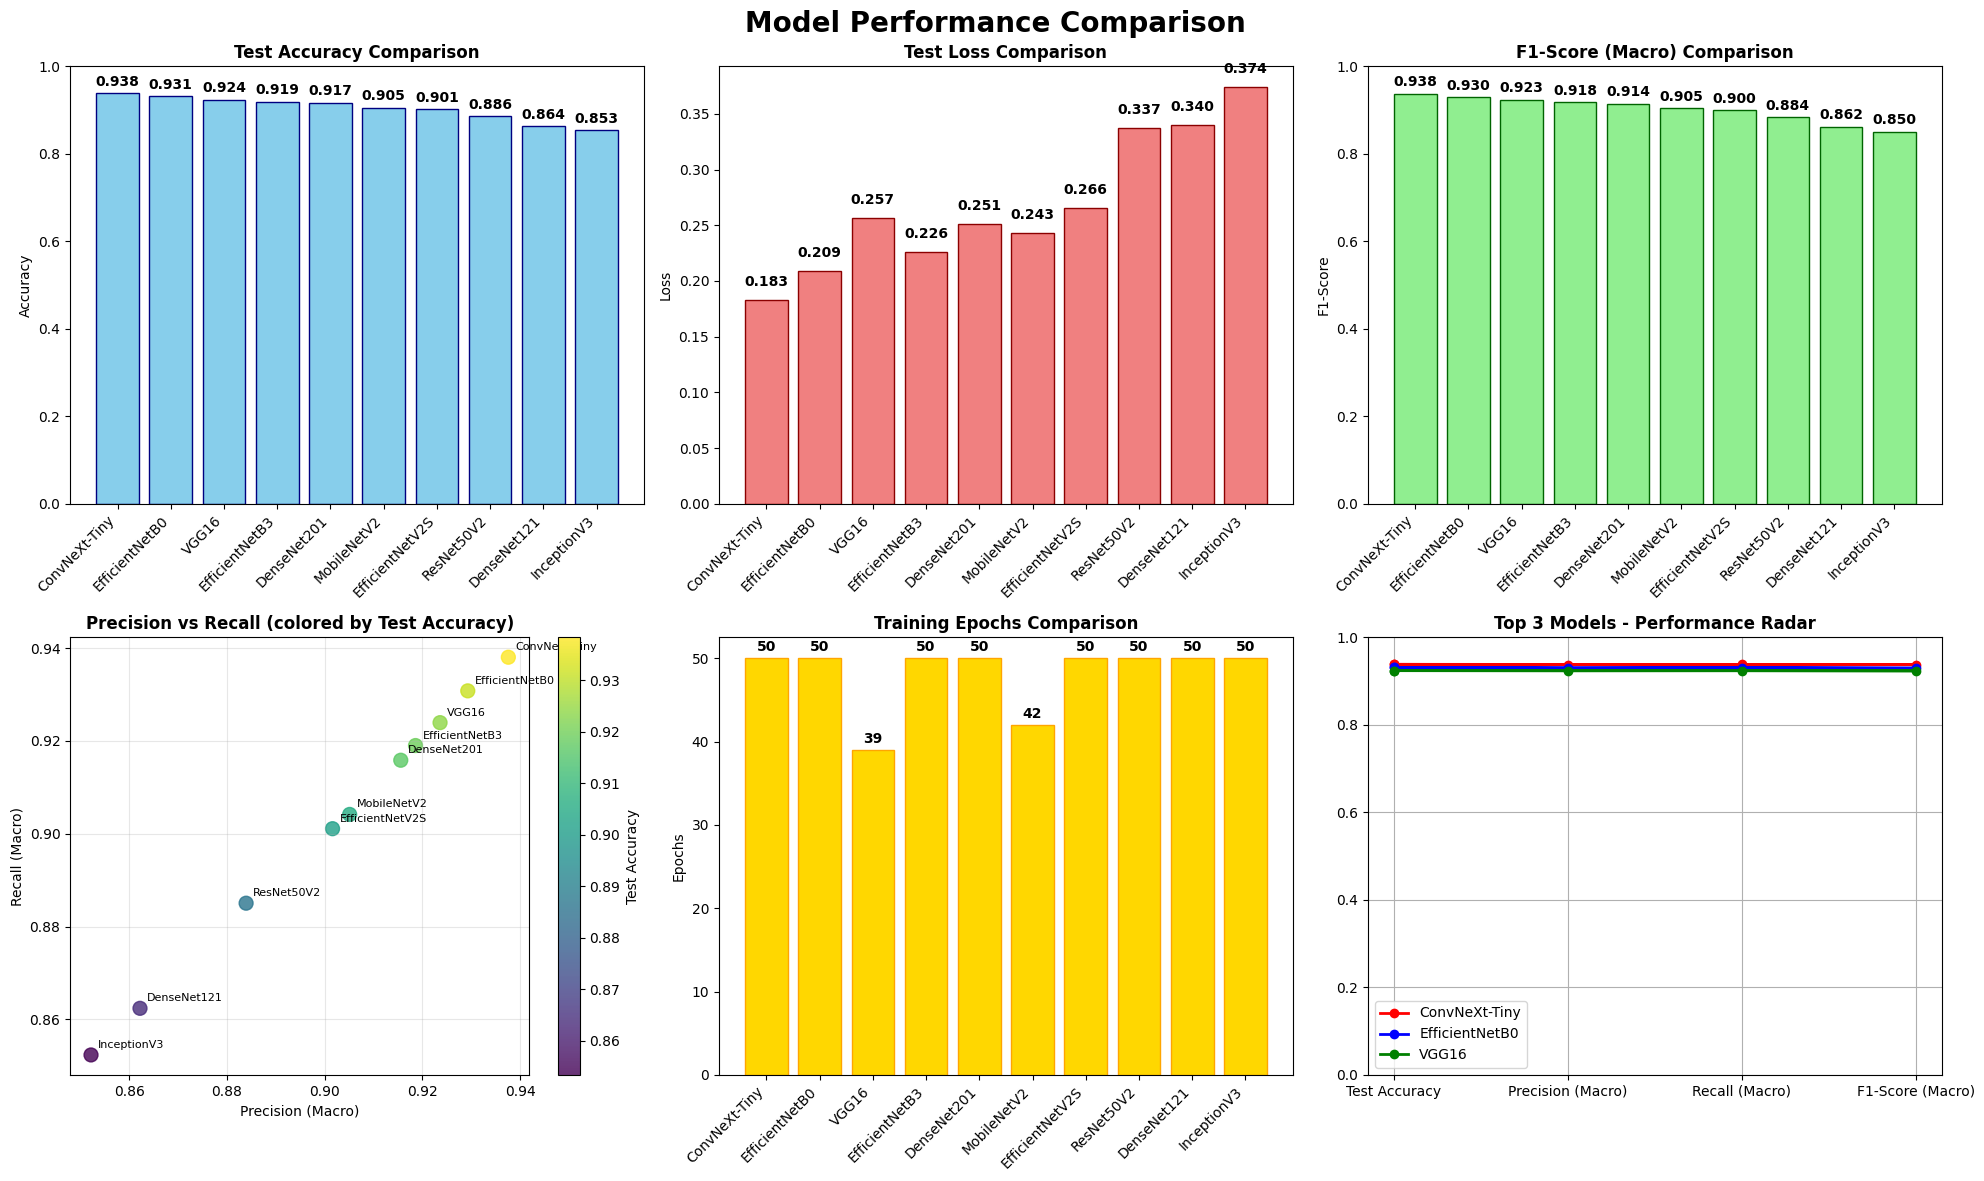

✅ Comparison plot saved to: /content/drive/MyDrive/dental_models_comparison/model_comparison_plot.png


<Figure size 640x480 with 0 Axes>

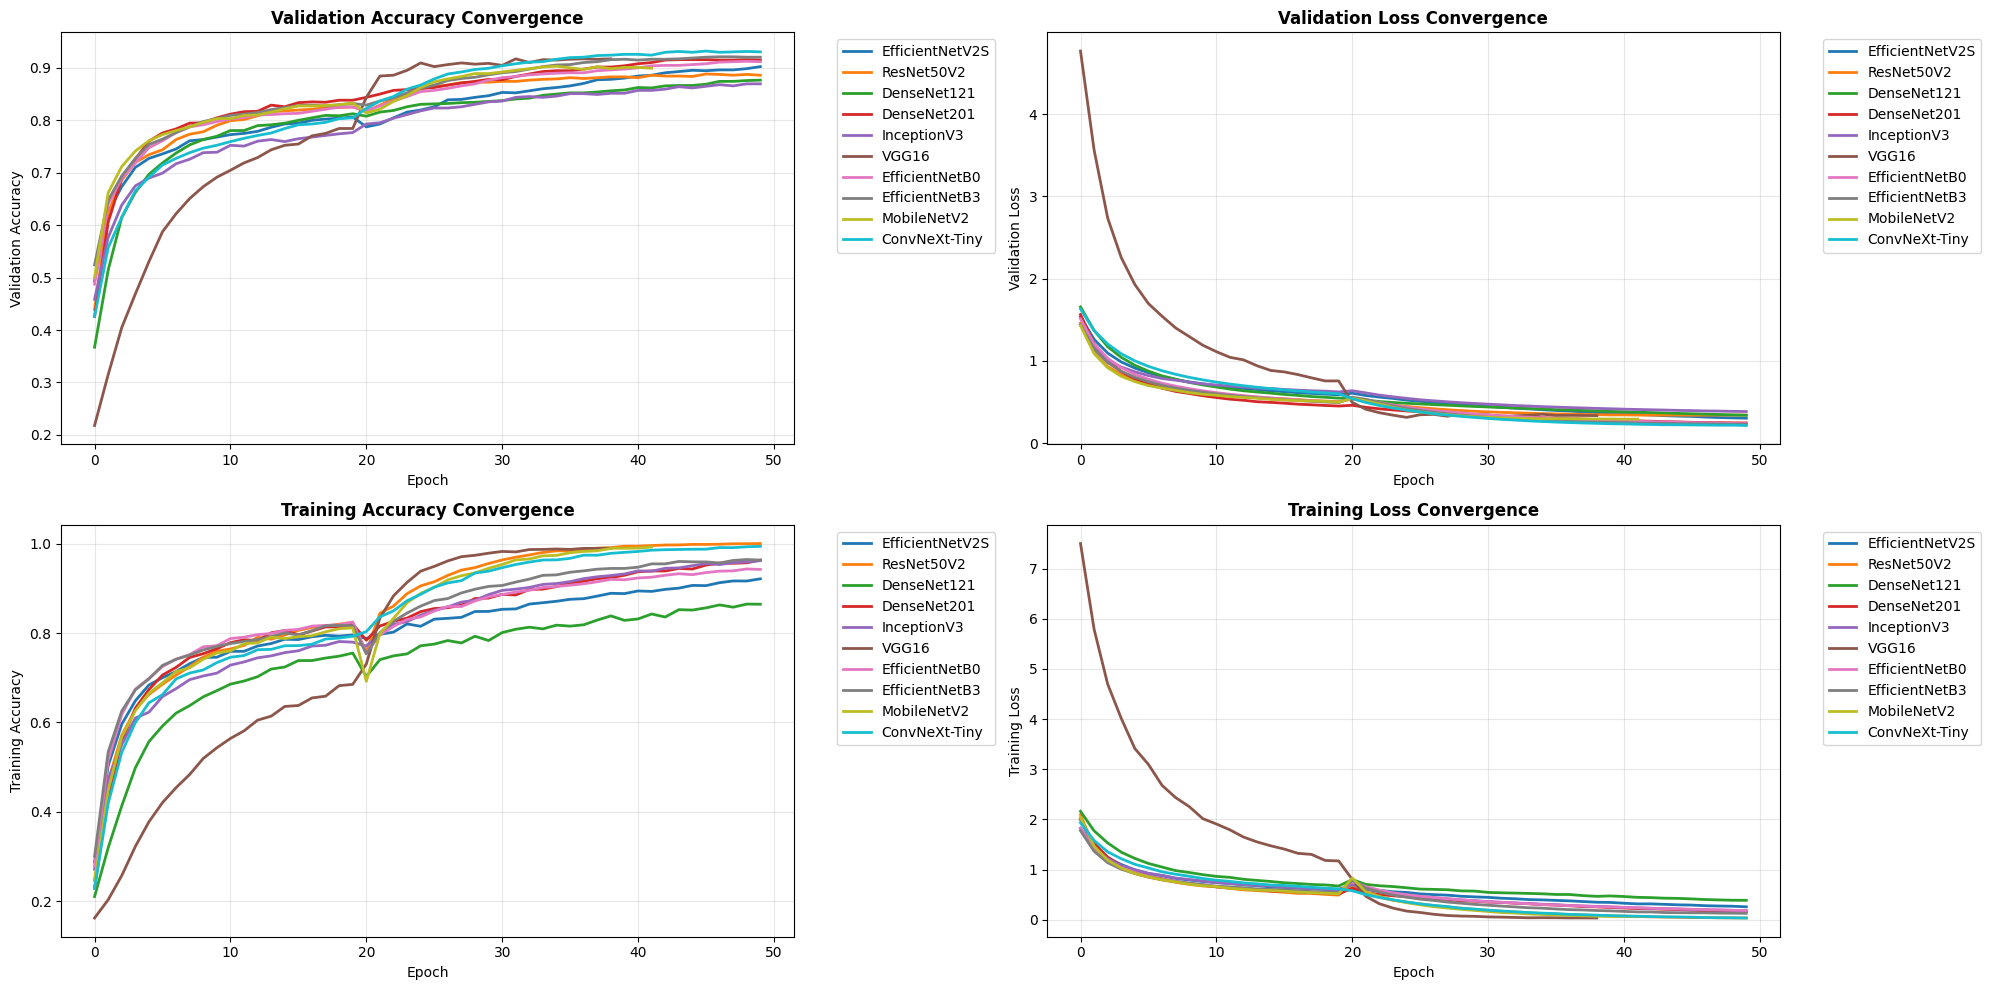

✅ Convergence plot saved to: /content/drive/MyDrive/dental_models_comparison/training_convergence_plot.png
📄 DETAILED ANALYSIS REPORT
# Dental Classification Model Comparison Report
Generated on: 2025-07-16 10:04:41

## Dataset Summary
- Total Classes: 7
- Class Names: Calculus, Caries, Gingivitis, Healthy, Hypodontia, Tooth_discoloration, Ulcers
- Image Size: (224, 224)
- Batch Size: 32

## Models Evaluated
1. EfficientNetV2S
2. ResNet50V2
3. DenseNet121
4. DenseNet201
5. InceptionV3
6. VGG16
7. EfficientNetB0
8. EfficientNetB3
9. MobileNetV2
10. ConvNeXt-Tiny

## Performance Ranking
### By Test Accuracy:
1. ConvNeXt-Tiny: 0.9383
2. EfficientNetB0: 0.9311
3. VGG16: 0.9239
4. EfficientNetB3: 0.9191
5. DenseNet201: 0.9167
6. MobileNetV2: 0.9054
7. EfficientNetV2S: 0.9014
8. ResNet50V2: 0.8862
9. DenseNet121: 0.8638
10. InceptionV3: 0.8534

## Best Model Analysis
**Best Model: ConvNeXt-Tiny**
- Test Accuracy: 0.9383
- Test Loss: 0.1829
- Macro F1-Score: 0.9376

### Per-Class Performance 

<Figure size 640x480 with 0 Axes>

In [ ]:
# ==================== CELL 18: COMPREHENSIVE RESULTS COMPARISON ====================
def create_comparison_summary():
    """Create comprehensive comparison of all models"""
    print("=== COMPREHENSIVE MODEL COMPARISON ===")

    # Load results if not in memory
    results_path = os.path.join(RESULTS_BASE_PATH, 'comparison_results.json')
    if os.path.exists(results_path):
        with open(results_path, 'r') as f:
            model_results = json.load(f)

    # Create comparison DataFrame
    comparison_data = []
    for model_name, data in model_results.items():
        results = data['results']
        history = data['history']

        comparison_data.append({
            'Model': model_name,
            'Test Accuracy': results['test_accuracy'],
            'Test Loss': results['test_loss'],
            'Best Val Accuracy': max(history['val_accuracy']),
            'Best Val Loss': min(history['val_loss']),
            'Training Epochs': len(history['accuracy']),
            'Precision (Macro)': results['classification_report']['macro avg']['precision'],
            'Recall (Macro)': results['classification_report']['macro avg']['recall'],
            'F1-Score (Macro)': results['classification_report']['macro avg']['f1-score']
        })

    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values('Test Accuracy', ascending=False)

    print("\n📊 MODEL COMPARISON SUMMARY:")
    print("=" * 120)
    print(comparison_df.to_string(index=False, float_format='%.4f'))

    # Save comparison to CSV
    comparison_path = os.path.join(RESULTS_BASE_PATH, 'model_comparison.csv')
    comparison_df.to_csv(comparison_path, index=False)
    print(f"\n✅ Comparison saved to: {comparison_path}")

    return comparison_df

def plot_model_comparison(comparison_df):
    """Create comprehensive visualization of model comparison"""

    # Set up the plotting style
    plt.style.use('default')
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('Model Performance Comparison', fontsize=20, fontweight='bold')

    # 1. Test Accuracy Comparison
    ax1 = axes[0, 0]
    bars1 = ax1.bar(comparison_df['Model'], comparison_df['Test Accuracy'],
                    color='skyblue', edgecolor='navy', linewidth=1)
    ax1.set_title('Test Accuracy Comparison', fontweight='bold')
    ax1.set_ylabel('Accuracy')
    ax1.set_ylim(0, 1)
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

    # 2. Test Loss Comparison
    ax2 = axes[0, 1]
    bars2 = ax2.bar(comparison_df['Model'], comparison_df['Test Loss'],
                    color='lightcoral', edgecolor='darkred', linewidth=1)
    ax2.set_title('Test Loss Comparison', fontweight='bold')
    ax2.set_ylabel('Loss')
    plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

    # Add value labels on bars
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

    # 3. F1-Score Comparison
    ax3 = axes[0, 2]
    bars3 = ax3.bar(comparison_df['Model'], comparison_df['F1-Score (Macro)'],
                    color='lightgreen', edgecolor='darkgreen', linewidth=1)
    ax3.set_title('F1-Score (Macro) Comparison', fontweight='bold')
    ax3.set_ylabel('F1-Score')
    ax3.set_ylim(0, 1)
    plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')

    # Add value labels on bars
    for bar in bars3:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

    # 4. Precision vs Recall Scatter
    ax4 = axes[1, 0]
    scatter = ax4.scatter(comparison_df['Precision (Macro)'], comparison_df['Recall (Macro)'],
                         c=comparison_df['Test Accuracy'], cmap='viridis', s=100, alpha=0.8)
    ax4.set_title('Precision vs Recall (colored by Test Accuracy)', fontweight='bold')
    ax4.set_xlabel('Precision (Macro)')
    ax4.set_ylabel('Recall (Macro)')
    ax4.grid(True, alpha=0.3)

    # Add model names as annotations
    for i, model in enumerate(comparison_df['Model']):
        ax4.annotate(model, (comparison_df['Precision (Macro)'].iloc[i],
                           comparison_df['Recall (Macro)'].iloc[i]),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('Test Accuracy')

    # 5. Training Epochs Comparison
    ax5 = axes[1, 1]
    bars5 = ax5.bar(comparison_df['Model'], comparison_df['Training Epochs'],
                    color='gold', edgecolor='orange', linewidth=1)
    ax5.set_title('Training Epochs Comparison', fontweight='bold')
    ax5.set_ylabel('Epochs')
    plt.setp(ax5.get_xticklabels(), rotation=45, ha='right')

    # Add value labels on bars
    for bar in bars5:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

    # 6. Top 3 Models Radar Chart
    ax6 = axes[1, 2]
    top3_models = comparison_df.head(3)

    # Create radar chart data
    metrics = ['Test Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)']
    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]  # Complete the circle

    colors = ['red', 'blue', 'green']
    for i, (_, model_data) in enumerate(top3_models.iterrows()):
        values = [model_data[metric] for metric in metrics]
        values += values[:1]  # Complete the circle

        ax6.plot(angles, values, 'o-', linewidth=2, label=model_data['Model'], color=colors[i])
        ax6.fill(angles, values, alpha=0.25, color=colors[i])

    ax6.set_xticks(angles[:-1])
    ax6.set_xticklabels(metrics)
    ax6.set_ylim(0, 1)
    ax6.set_title('Top 3 Models - Performance Radar', fontweight='bold')
    ax6.legend()
    ax6.grid(True)

    plt.tight_layout()
    plt.show()

    # Save the comparison plot
    comparison_plot_path = os.path.join(RESULTS_BASE_PATH, 'model_comparison_plot.png')
    plt.savefig(comparison_plot_path, dpi=300, bbox_inches='tight')
    print(f"✅ Comparison plot saved to: {comparison_plot_path}")

def plot_training_convergence():
    """Plot training convergence for all models"""

    # Load results if not in memory
    results_path = os.path.join(RESULTS_BASE_PATH, 'comparison_results.json')
    if os.path.exists(results_path):
        with open(results_path, 'r') as f:
            model_results = json.load(f)

    plt.figure(figsize=(20, 10))

    # Plot validation accuracy convergence
    plt.subplot(2, 2, 1)
    for model_name, data in model_results.items():
        history = data['history']
        plt.plot(history['val_accuracy'], label=model_name, linewidth=2)
    plt.title('Validation Accuracy Convergence', fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Plot validation loss convergence
    plt.subplot(2, 2, 2)
    for model_name, data in model_results.items():
        history = data['history']
        plt.plot(history['val_loss'], label=model_name, linewidth=2)
    plt.title('Validation Loss Convergence', fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Loss')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Plot training accuracy convergence
    plt.subplot(2, 2, 3)
    for model_name, data in model_results.items():
        history = data['history']
        plt.plot(history['accuracy'], label=model_name, linewidth=2)
    plt.title('Training Accuracy Convergence', fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Training Accuracy')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Plot training loss convergence
    plt.subplot(2, 2, 4)
    for model_name, data in model_results.items():
        history = data['history']
        plt.plot(history['loss'], label=model_name, linewidth=2)
    plt.title('Training Loss Convergence', fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Save convergence plot
    convergence_plot_path = os.path.join(RESULTS_BASE_PATH, 'training_convergence_plot.png')
    plt.savefig(convergence_plot_path, dpi=300, bbox_inches='tight')
    print(f"✅ Convergence plot saved to: {convergence_plot_path}")

def generate_detailed_report():
    """Generate detailed analysis report"""

    # Load results if not in memory
    results_path = os.path.join(RESULTS_BASE_PATH, 'comparison_results.json')
    if os.path.exists(results_path):
        with open(results_path, 'r') as f:
            model_results = json.load(f)

    report = []
    report.append("# Dental Classification Model Comparison Report")
    report.append(f"Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    report.append("")

    # Dataset summary
    report.append("## Dataset Summary")
    report.append(f"- Total Classes: {NUM_CLASSES}")
    report.append(f"- Class Names: {', '.join(CLASS_NAMES)}")
    report.append(f"- Image Size: {IMG_SIZE}")
    report.append(f"- Batch Size: {BATCH_SIZE}")
    report.append("")

    # Model summary
    report.append("## Models Evaluated")
    for i, model_name in enumerate(model_results.keys(), 1):
        report.append(f"{i}. {model_name}")
    report.append("")

    # Performance ranking
    comparison_data = []
    for model_name, data in model_results.items():
        results = data['results']
        comparison_data.append({
            'Model': model_name,
            'Test Accuracy': results['test_accuracy'],
            'F1-Score': results['classification_report']['macro avg']['f1-score']
        })

    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.sort_values('Test Accuracy', ascending=False)

    report.append("## Performance Ranking")
    report.append("### By Test Accuracy:")
    for i, (_, row) in enumerate(comparison_df.iterrows(), 1):
        report.append(f"{i}. {row['Model']}: {row['Test Accuracy']:.4f}")
    report.append("")

    # Best model analysis
    best_model = comparison_df.iloc[0]['Model']
    best_results = model_results[best_model]['results']

    report.append("## Best Model Analysis")
    report.append(f"**Best Model: {best_model}**")
    report.append(f"- Test Accuracy: {best_results['test_accuracy']:.4f}")
    report.append(f"- Test Loss: {best_results['test_loss']:.4f}")
    report.append(f"- Macro F1-Score: {best_results['classification_report']['macro avg']['f1-score']:.4f}")
    report.append("")

    # Per-class performance for best model
    report.append("### Per-Class Performance (Best Model):")
    for class_name in CLASS_NAMES:
        if class_name in best_results['classification_report']:
            class_metrics = best_results['classification_report'][class_name]
            report.append(f"- {class_name}:")
            report.append(f"  - Precision: {class_metrics['precision']:.4f}")
            report.append(f"  - Recall: {class_metrics['recall']:.4f}")
            report.append(f"  - F1-Score: {class_metrics['f1-score']:.4f}")
    report.append("")

    # Recommendations
    report.append("## Recommendations")
    report.append("1. **Production Model**: Use the best performing model for deployment")
    report.append("2. **Resource Constraints**: Consider MobileNetV2 for mobile/edge deployment")
    report.append("3. **Further Improvements**: Consider ensemble methods combining top models")
    report.append("4. **Data Augmentation**: Review classes with lower performance for targeted augmentation")
    report.append("")

    # Save report
    report_text = "\n".join(report)
    report_path = os.path.join(RESULTS_BASE_PATH, 'detailed_analysis_report.md')
    with open(report_path, 'w') as f:
        f.write(report_text)

    print("📄 DETAILED ANALYSIS REPORT")
    print("=" * 50)
    print(report_text)
    print(f"\n✅ Report saved to: {report_path}")

# Run comprehensive analysis
comparison_df = create_comparison_summary()
plot_model_comparison(comparison_df)
plot_training_convergence()
generate_detailed_report()

print("\n🎉 COMPLETE MODEL COMPARISON FINISHED!")
print("=" * 60)
print("All models have been trained, evaluated, and compared.")
print(f"Results saved in: {RESULTS_BASE_PATH}")
print("\nFiles generated:")
print("- comparison_results.json (raw results)")
print("- model_comparison.csv (summary table)")
print("- model_comparison_plot.png (visual comparison)")
print("- training_convergence_plot.png (training curves)")
print("- detailed_analysis_report.md (comprehensive report)")
print("- individual model files (*_best.keras)")